# **Istraživanje faktora povezanih sa dijabetesom: Analiza različitih zdravstvenih parametara i njihov uticaj**


**TIM-29**

*   Lamija Dženetić - "Mjera zdravlja: BMI, kožna struktura i dijabetes"
*   Ines Ćurdo - "Glukoza, insulin i njihova povezanost sa dijabetesom"
*   Amina Salkić - "Trudnoća i genetička predispozicija za dijabetes"
*   Nerina Čengić - "Starosna dob i krvni pritisak u korelaciji sa dijabetesom"



*   "Zaključak" - nakon posebno ispitanih relacija zajedno smo postavile dodatne hipoteze te donijele zaključke, i jednako učestvovale u njihovoj izradi

Prijedlog bodovanja


*   Radi podjednakog, skladnog rada i zalaganja cijelog tima smatramo da svaki član zaslužuje 100% prilikom bodovanja.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
print(df.head(10))


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   2

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#VELICINA DATASET-A
df.shape

(768, 9)

In [ ]:
#TIPOVI VARIJABLI
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#DESKRIPTIVNA STATISTIKA ZA SVE VARIJABLE U SETU PODATAKA
df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<ipython-input-47-1d52ae2e1b7c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=colors)


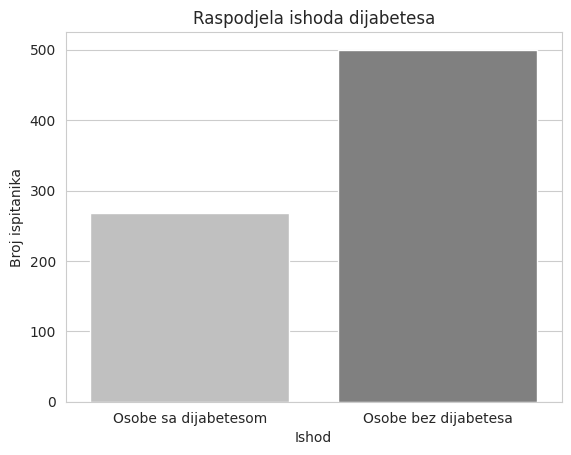

In [ ]:
import seaborn as sns
colors = ["silver", "gray"]
df['Outcome'] = df['Outcome'].replace({0: 'Osobe bez dijabetesa', 1: 'Osobe sa dijabetesom'})
sns.countplot(x='Outcome', data=df, palette=colors)
plt.xlabel('Ishod')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela ishoda dijabetesa')
plt.show()

Ova analiza uzoraka nam pokazuje da u našem dataset-u postoji gotovo dvostruko više ispitanika koji nemaju dijabetes u usporedbi s onima koji imaju dijabetes. Ova dominacija ispitanika bez dijabetesa može ukazivati na postojanje važnih faktora ili predispozicija koje mogu uticati na razvoj ili odsustvo dijabetesa. U skladu s tim, može se potaknuti dalje istraživanje kako bi se bolje razumjeli ovi faktori i njihov uticaj na zdravlje.

# **Mjera zdravlja: BMI, kožna struktura i dijabetes**

U zdravstvenoj analizi, razmatranje BMI-a i debljine kože predstavlja važan korak ka razumijevanju potencijalnih zdravstvenih izazova. Istraživanja su pokazala da postoji čvrsta veza između BMI-a, debljine kože i povećanog rizika od dijabetesa. Naprimjer, visok BMI često ukazuje na prekomjernu tjelesnu težinu, što može izazvati metaboličke poremećaje, uključujući inzulinsku rezistenciju koja je vrlo često prethodnik dijabetesa tipa 2. Slično tome, povećana debljina kože može biti pokazatelj viceralne masti, koja je također povezana s metaboličkim rizicima. Razumijevanje ove veze omogućava nam da identificiramo rizične populacije i poduzmemo korake ka prevenciji i upravljajnu dijabetesom. Stoga, uzimajući u obzir ove faktore, pružamo sebi priliku da djelujemo proaktivno u očuvanju zdravlja i sprječavanju ozbiljnih zdravstvenih problema.

Na osnovu našeg dataset-a, istražit ćemo vezu izmedu indeksa tjelesne mase (BMI) i debljine kože, te njihov potencijalni uticaj na zdravlje pojedinaca. Na samom početku naše analize izračunat ćemo srednju vrijednost, medijanu, varijansu i standardnu devijaciju pojedinačno za ove dvije varijable, a u nastavku analizirat ćemo na koji način su one povezane i kako njihova veza utiče na pojavu dijabetesa.

In [ ]:
#STANDARDNA DEVIJACIJA, VARIJANSA, MEDIJAN I SREDNJA VRIJEDNOST
print('Srednja vrijednost za BMI:', df['BMI'].mean())
print('Standardna devijacija za BMI:',df['BMI'].std())
print('Medijan za BMI:', df['BMI'].median())
print('Varijansa za BMI:', df['BMI'].var())


Srednja vrijednost za BMI: 31.992578124999998
Standardna devijacija za BMI: 7.884160320375446
Medijan za BMI: 32.0
Varijansa za BMI: 62.15998395738266


In [ ]:
print('Srednja vrijednost za debljinu kože:', df['SkinThickness'].mean())
print('Standardna devijacija za debljinu kože:',df['SkinThickness'].std())
print('Medijan za debljinu kože:', df['SkinThickness'].median())
print('Varijansa za debljinu kože:', df['SkinThickness'].var())


Srednja vrijednost za debljinu kože: 20.536458333333332
Standardna devijacija za debljinu kože: 15.952217567727637
Medijan za debljinu kože: 23.0
Varijansa za debljinu kože: 254.47324532811822


In [ ]:
df['BMI'].describe()

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [ ]:
df['SkinThickness'].describe()

count    768.000000
mean      20.536458
std       15.952218
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

**Analiza distribucije za pojedine varijable (BMI, SkinThickness)**

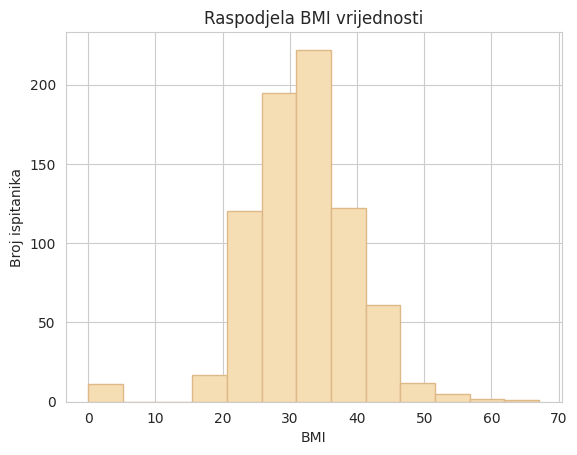

In [ ]:
import matplotlib.pyplot as plt

# Postavljanje granica intervala (bins) tako da odgovaraju vašim zahtjevima
bins = [1, 2, 3, 4, 5]

# Kreiranje histograma
plt.hist(df['Promjene raspoloženja'], bins=bins, color='wheat', edgecolor='burlywood', align='left', rwidth=0.8)

# Postavljanje oznaka na osi x
plt.xticks(range(1, 5))

# Dodavanje oznaka i naslova
plt.xlabel('Promjene raspoloženja')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela vrijednosti promjene raspoloženja')

# Prikaz histograma
plt.show()


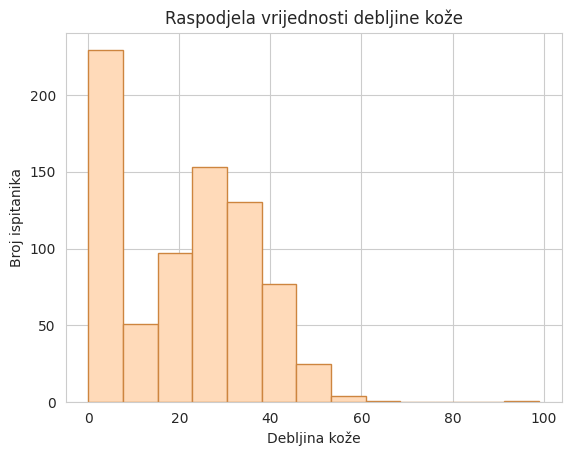

In [ ]:
plt.hist(df['SkinThickness'], bins=13, color='peachpuff', edgecolor='peru')
plt.xlabel('Debljina kože')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela vrijednosti debljine kože')
plt.show()

Iz ova dva histograma vidimo na koji način su izvršene raspodjele varijabli u našem dataset-u. Za vrijednosti BMI možemo reći da su raspoređene poprilično simetrično u odnosu na njihovu srednju vrijednost, ako izuzmemo pojedine uzorke. Dok je sasvim drugi slučaj kod drugog histograma. Vidimo da se najveća vrijednost očitava na samom početku, što znači da je najveći broj ispitanika koncentriran upravo u prvom rasponu vrijednosti.  

Izračunat ćemo matematsko očekivanje (očekivanu vrijednost) za BMI i strukturu kože

In [ ]:
hist, bins = np.histogram(df['BMI'], bins='auto')
weighted_mean_bmi=np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost BMI:', weighted_mean_bmi)

Očekivana vrijednost BMI: 31.03426393995098


In [ ]:
hist, bins = np.histogram(df['SkinThickness'], bins='auto')
weighted_mean_skinthickness = np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost debljine kože: ', weighted_mean_skinthickness)

Očekivana vrijednost debljine kože:  18.210156249999997


Sada možemo uporediti očekivanu vrijednost sa srednjom vrijednosti varijabli. Ranije smo izračunali da srednja vrijednost BMI-a iznosi 31.992578124999998. Uporedimo li tu vrijednost sa očekivanom vrijednošću možemo reći da su približno jednake, razlika se javlja tek na decimalnim mjestima. Ovim smo utvrdili da distribucija tih podataka nije značajno asimetrična. S druge strane razlika izmedju srednje vrijedosti debljine kože koja iznosi 20.536458333333332 i očekivane vrijednosti od 18.210156249999997 ukazuje na asimetriju u distribuciji podataka. To može značiti da postoje ekstremne vrijednosti koje mogu uticati na srednju vrijednost.

**Postoji li velika razlika u vrijednostima BMI i debljine kože između osoba sa dijabetesom i zdravih osoba?**

Odgovor na ovo pitanje tražit ćemo koristeći scatter-plot, gdje kao parametre koji se mijenjaju navodimo pomenute varijable, a osobe ćemo označiti različitim bojama kako bismo mogli odmah uočiti potencijalne razlike u variranju.

[1 0]
Diabetic Count: 268
Non-Diabetic Count: 500


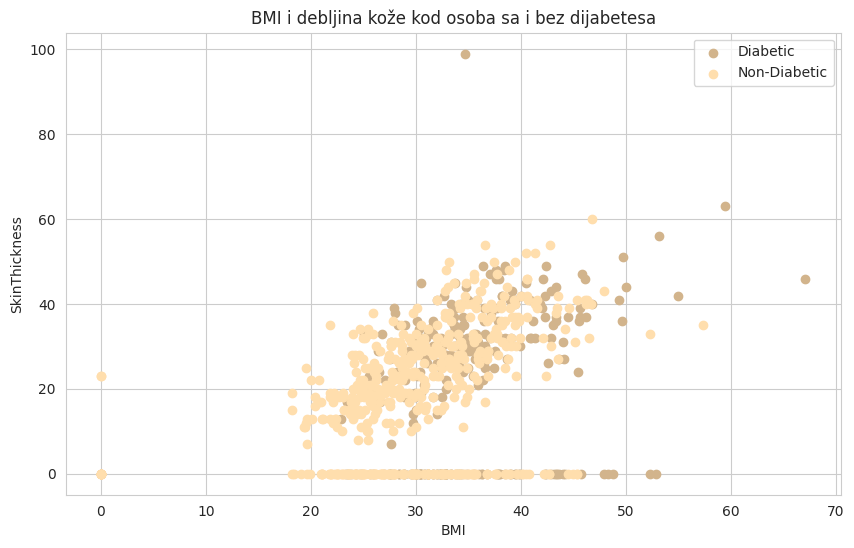

In [ ]:
# Mapping strings to numerical values
outcome_map = {'Osobe sa dijabetesom': 1, 'Osobe bez dijabetesa': 0}
df['Outcome'] = df['Outcome'].map(outcome_map)

# Check unique values to confirm it's 0 and 1 now
print(df['Outcome'].unique())

# Now filter diabetic and non-diabetic individuals
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

print("Diabetic Count:", len(diabetic))
print("Non-Diabetic Count:", len(non_diabetic))

# Plotting
plt.figure(figsize=(10, 6))

# Plot diabetic individuals
plt.scatter(diabetic['BMI'], diabetic['SkinThickness'], color='tan', label='Diabetic')

# Plot non-diabetic individuals
plt.scatter(non_diabetic['BMI'], non_diabetic['SkinThickness'], color='navajowhite', label='Non-Diabetic')

plt.xlabel('BMI')
plt.ylabel('SkinThickness')
plt.title('BMI i debljina kože kod osoba sa i bez dijabetesa')
plt.legend()
plt.show()







Na osnovu ovog scatter-plota možemo reći da ne postoji velika razlika između vrijednosti ovih varijabli kod osoba sa dijagnozom i osoba bez dijagnoze. Štaviše, kružići su skoncentrisani oko jednog mjesta te dolazi i do preklapanja, a pritom pojedine uzorke koji predstavljaju neobične ili ekstremne vrijednosti (outliers) možemo odbaciti kako ne bi prouzrokovali greške u mjerenju.

Bitno je objasniti tačke koje su postavljene na vrijednosti nula. Kao što vidimo, imamo mnogo tačaka koje se preklapaju i imaju neke optimalne vrijednosti BMI, dok je vrijednost debljine kože, očitana sa ovog scatter plota, jednak nuli. Postoji više razloga koji mogu dovesti do ovakve situacije. Jedan od njih je postojanje nule kao stvarne vrijednosti podataka, što bi značilo da značajan dio podataka poprima vrijednost nula, gledajući kožnu strukturu. Drugi potencijalni razlog ove pojave može biti rezultat grešaka prilikom mjerenja ili ograničenja u prikupljanju podataka. To u nekim slučajevima može ukazivati na nepostojeće podatke koji utiču na samu analizu. S obzirom na veći broj ovih potencijalnih razloga, važno je pažljivo analizirati kontekst i prirodu podataka s kojim radimo, kako bismo bili u stanju donijeti adekvatne zaključke.

U našem slučaju, nakon još jedne detaljnije analize dataset-a, zaključili smo da u kolona sa vrijednostima mjerne jedinice debljine kože sadrži veliki broj podataka koji su jednaki nuli. To bi značilo da tačke koje su postavljene na vrijednost nula, posmatrajući osu sa podacima debljine kože("SkinThickness"), imaju stvarnu vrijednost nula. To zapažanje nam je dalo motivaciju da budemo sigurniji pri donošenju konačnog suda, jer smo na neki način uvidjeli da nije u pitanju greška u podacima ili mjerenju.


Pogledajmo kako se odnose vrijednosti BMI upoređujući osobe sa dijagnosticiranim dijabetesom i osobe koje nemaju ovu bolest

<Axes: xlabel='Outcome', ylabel='BMI'>

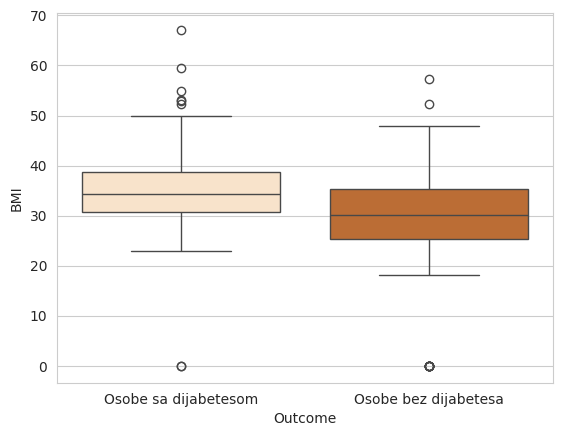

In [ ]:
import seaborn as sns
ccolors=["bisque", "chocolate"]
df['Outcome'] = df['Outcome'].replace({0: 'Osobe bez dijabetesa', 1: 'Osobe sa dijabetesom'})

sns.boxplot(x='Outcome', y='BMI', data=df, hue='Outcome', palette=ccolors)

Na osnovu ove vizualizacije dolazimo do zaključka da osobe sa većom vrijednošću BMI-a potencijalno mogu biti nosioci ove bolesti. Veći BMI je u dosta slučajeva povezan sa pretilošću, što je poznati faktor rizika za dijabetes. Sve to vidimo posmatrajući porast varijable BMI kod osoba kod kojih je dijagnosticiran dijabetes u odnosu na osobe koje nisu dijabetičari. To može ukazivati na potrebu za promjenom životnih navika, poput prehrambenih navika ili tjelesne aktivnosti, kako bi se smanjio rizik od razvoja dijabetesa. Možemo zaključiti da postoje ekstremne minimalne i maksimalne vrijednosti kod obje skupine. Kada govorimo o vrijednostima koje idu ispod minimuma one su u oba slucaja jednake nuli, dok vrijednosti koje premašuju maksimum imamo više. Ako bismo posmatrali razlikuju li se među skupinama, odgovor bi bio potvrdan jer kod skupine sa dijabetesom se uočava znatno više outlier-a u odnosu na skupinu bez dijabetesa, i oni poprimaju različite vrijednosti.

---



**Može li se utvrditi neka povezanost između vrijednosti BMI-a i debljine kože?**

Pokušat ćemo to provjeriti tako što izračunamo kovarijansu koja predstavlja kako dvije varijable variraju zajedno. Kovarijansa je pozitivna ako varijable imaju tendenciju rasti zajedno, negativna ako zajedno opadaju, a blizu vrijednosti nule ako nema jasne veze između njih.

In [ ]:
covariance=df['BMI'].cov(df['SkinThickness'])
print('Kovarijansa između BMI-a i debljine kože je: ', covariance)

Kovarijansa između BMI-a i debljine kože je:  49.373869377444585


Na osnovu rezultata koji smo dobili računanjem kovarijanse možemo zaključiti da ove dvije varijable imaju tendenciju da rastu zajedno, tj. postoji pozitivna linearna veza između njih, što znači da kada se vrijednost jedne varijable povećava, analogno se povećava i vrijednost druge varijable. Međutim, kovarijansa nam ne pruža baš punu sliku jačine ili smjera veze između varijabli. Upravo iz tog razloga ćemo izračunati faktor korelacije te prikazati grafički vezu BMI i debljine kože.

In [ ]:
correlation=df['BMI'].corr(df['SkinThickness'])
print('Faktor korelacije između BMI i debljine kože', correlation)

Faktor korelacije između BMI i debljine kože 0.3925732041590384


Dobijeni faktor korelacije nam ukazuje na to da postoji umjerena pozitivna korelacija između posmatranih varijabli. Iako se ovakve veze smatraju tipom umjerenih veza, rezultat nas dovodi do zaključka da ovakve veze i nisu toliko jake da bismo mogli izvesti neke snažne zaključke o povezanosti varijabli. To bi u osnovici značilo da između njih postoji neka vrsta veze, ali da se one ne mijenjaju u potpunosti zajedno.

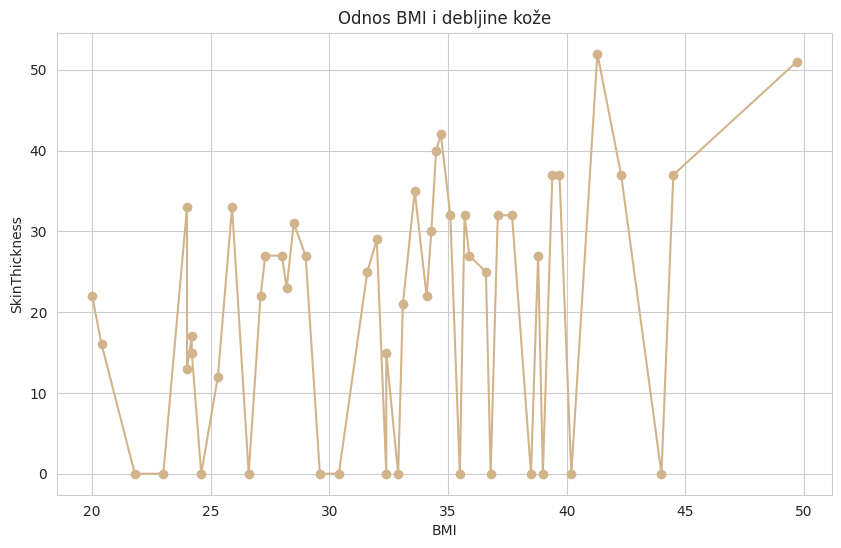

In [ ]:
N=50
random_sample=df.sample(n=N)
sample_sorted=random_sample.sort_values(by='BMI')
plt.figure(figsize=(10,6))
plt.plot(sample_sorted['BMI'], sample_sorted['SkinThickness'], marker='o', linestyle='-', color='tan')
plt.title('Odnos BMI i debljine kože')
plt.xlabel('BMI')
plt.ylabel('SkinThickness')
plt.grid(True)
plt.show()

Nasumičnim odabirom uzoraka iz seta podataka kreirali smo pregledniji grafik na osnovu kojeg možemo donijeti konačan sud. Ova vizualizacija nam je omogućila da jasno vidimo na koji način se ponašaju dvije varijable i kakva je njihova međusobna povezanost. Dakle, rezultat vizualizacije je potvrdio prethodni zaključak koji smo donijeli nakon računanja stepena korelacije. Očigledno je da se varijable ne mijenjaju u potpunosti zajedno, što znači da porast jedne varijable ne implicira uvijek porast druge varijable. Drugim riječima, promjene u jednoj varijabli djelimično prate promjene u drugoj varijabli, ali ne nužno u potpunosti. Konačan zaključak je da postoji neka veza između ovih varijabli, no ona nije dovoljno pouzdana da na osnovu nje donosimo pojedine zaključke.

**Jesu li stariji ljudi skloniji imati viši ili niži BMI?**

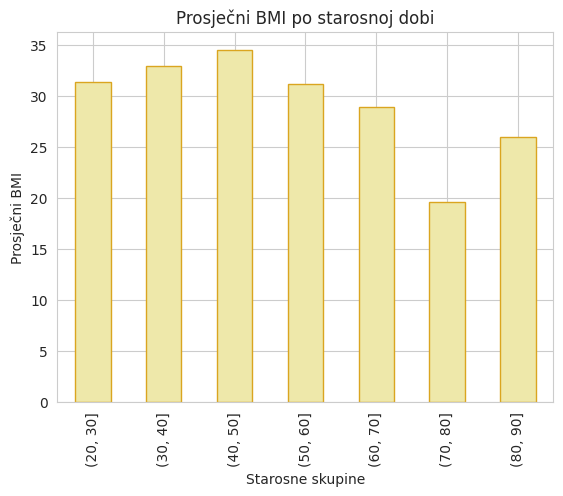

In [ ]:
df['AgeGroup']=pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 80, 90])
grouped=df.groupby('AgeGroup')

average_bmi=grouped['BMI'].mean()

average_bmi.plot(kind='bar', color='palegoldenrod', edgecolor='goldenrod')
plt.xlabel('Starosne skupine')
plt.ylabel('Prosječni BMI')
plt.title('Prosječni BMI po starosnoj dobi')
plt.show()

Analizom ovog dijagrama možemo izvesti zaključak da najveću vrijednost indeksa tjelesne mase u prosjeku imaju osobe između 40 i 50 godina, dok najmanju vrijednost uočavamo kod osoba od 70 do 80 godina starosti. Odgovor na naše postavljeno pitanje je da stariji ljudi pretežno imaju niže vrijednosti BMI. Ovo nam daje poveznicu sa ranije donesenim zaključkom da su osobe sa visokom vrijednosti BMI-a sklonije oboljenju, stoga možemo tvrditi da je najveća mogućnost da osoba sa dijabetesom pripada dobnoj skupini od 40 do 50 godina, što se smatra srednjom starosnom dobi.

**Može li debljina kože biti pokazatelj rizika od dijabetesa?**

<ipython-input-64-b16a83e06524>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='SkinThickness', data=df, palette=c)


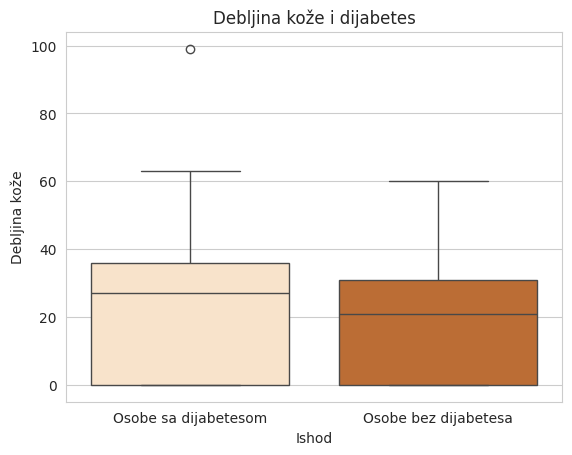

In [ ]:
c=["bisque", "chocolate"]
sns.boxplot(x='Outcome', y='SkinThickness', data=df, palette=c)
plt.title('Debljina kože i dijabetes')
plt.xlabel('Ishod')
plt.ylabel('Debljina kože')
plt.show()

Ova dva box-plota nam pokazuju odnos između oboljelih i zdravih osoba na osnovu strukture kože. Stoga možemo očitati medijane i jedne i druge skupine. Medijana skupine kod koje je dijagnosticiran dijabetes je nešto malo veća od 20, dok je medijana druge skupine nešto malo niža od 30. Dolazimo do zaključka da su vrijednosti u nekoj mjeri približne tako da nema nekih velikih razlika. Također, sa grafika vidimo da nema produženog kraja za minimum box-plota što znači da minimalna vrijednost podataka nije toliko odstupala od prvog kvartila, to jeste podaci su relativno koncentrisani oko minimalne vrijednosti. Ovakav scenarij se događa kada su podaci raspoređeni relativno simetrično ili kada nema značajnih outliers-a na "nižoj" strani raspodjele. Može se reći da maksimum i jedne i druge skupine poprima vrijednost oko 60. U konačnici, te vrijednosti su približno jednake što ukazuje na to da su distribucije podataka za obje skupine slične na "gornjem" kraju spektra, te da je varijabilnost podataka ove dvije skupine slična. Bitno je naznačiti da kod skupine sa dijabetesom postoji ekstremna vrijednost koja iznosi oko 100 mjernih jedinica za debljinu kože, stoga svjesni njenog postojanja u nekim daljim proračunima taj uzorak možemo odbaciti kako ne bi uticao na željeni rezultat. Na osnovu vizualizacije i donesenih zaključaka možemo reći da debljina kože u većini slučajeva ne mora biti pokazatelj rizika od dijabetesa.


# Glukoza, insulin i njihova povezanost sa dijabetesom

Dijabetes pretstavlja globalni zdravstveni izazov sa sve većim brojem oboljelih širom svijeta. Ovaj kompleksni metabolički poremećaj karakteriše neregulisana koncentracija glukoze u krvi, što može imati ozbiljne posljedice po zdravlje. Glukoza, osnovni izvor energije za naše tijelo, igra ključnu ulogu u metabolizmu i regulaciji nivoa šećera u krvi. Sa druge strane, insulin, hormon koji proizvodi pankreas, od vitalnog je značaja za regulisanje metabolizma glukoze.

Povezanost između glukoze, insulina i dijabetesa je duboko složena i multidimenzionalna. Pokušat ćemo je otkriti i objasniti u narednim dijelovima našeg istraživanja.

In [ ]:
#STANDARDNA DEVIJACIJA, VARIJANSA, MEDIJAN I SREDNJA VRIJEDNOST
print('Srednja vrijednost za glukozu:', df['Glucose'].mean())
print('Standardna devijacija za glukozu:',df['Glucose'].std())
print('Medijan za glukozu:', df['Glucose'].median())
print('Varijansa za glukozu:', df['Glucose'].var())

Srednja vrijednost za glukozu: 120.89453125
Standardna devijacija za glukozu: 31.97261819513622
Medijan za glukozu: 117.0
Varijansa za glukozu: 1022.2483142519557


In [ ]:
#STANDARDNA DEVIJACIJA, VARIJANSA, MEDIJAN I SREDNJA VRIJEDNOST
print('Srednja vrijednost za insulin:', df['Insulin'].mean())
print('Standardna devijacija za insulin:',df['Insulin'].std())
print('Medijan za insulin:', df['Insulin'].median())
print('Varijansa za insulin:', df['Insulin'].var())

Srednja vrijednost za insulin: 79.79947916666667
Standardna devijacija za insulin: 115.24400235133817
Medijan za insulin: 30.5
Varijansa za insulin: 13281.180077955238


In [ ]:
df['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [ ]:
df['Insulin'].describe()

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

In [ ]:
hist, bins = np.histogram(df['Glucose'], bins='auto')
weighted_mean_glucose = np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost glukoze: ', weighted_mean_glucose)

Očekivana vrijednost glukoze:  116.36497961956523


In [ ]:
hist, bins = np.histogram(df['Insulin'], bins='auto')
weighted_mean_insulin = np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost insulina: ', weighted_mean_insulin)

Očekivana vrijednost insulina:  72.703125


Očekivana vrijednost glukoze je 111.25 dok je njena srednja vrijednost, ranije izračunata, 120.89453125. S obzirom da poželjne razlike u podacima bi bile samo u decimalnom zapisu, možemo zaključiti da ovi podaci imaju mnogo outlinera. Srednja vrijednost za insulin je 79.79947916666667 što je mnogo više od očekivane, pa je broj outlinera ogroman.

**Analiza distribucije za pojedine varijable (Glucose, Insulin)**

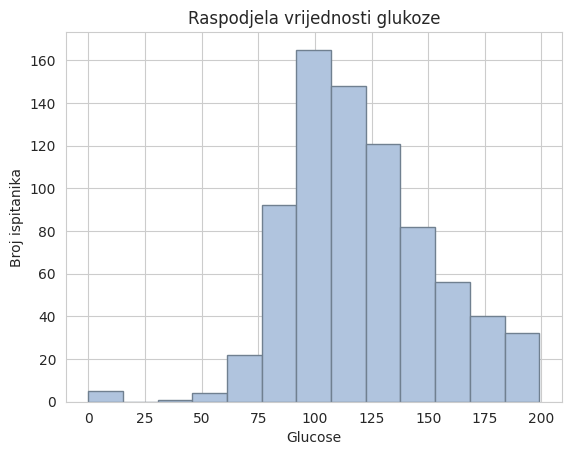

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Glucose'], bins=13, color='lightsteelblue', edgecolor='slategrey')
plt.xlabel('Glucose')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela vrijednosti glukoze')
plt.show()

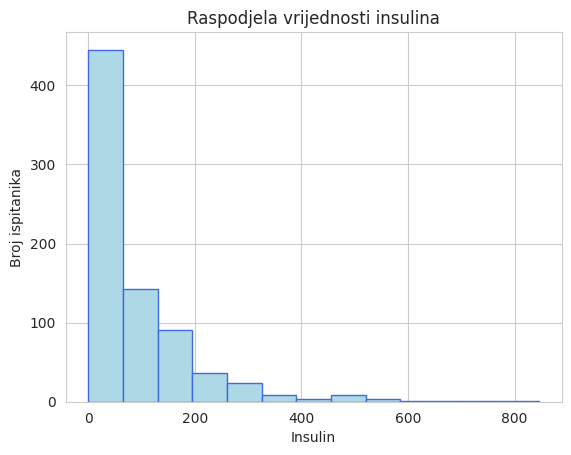

In [ ]:
plt.hist(df['Insulin'], bins=13, color='lightblue', edgecolor='royalblue')
plt.xlabel('Insulin')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela vrijednosti insulina')
plt.show()

Iz ova dva histograma vidimo na koji način su izvršene raspodjele varijabli u našem dataset-u. Za vrijednosti glukoze možemo reći da su raspoređene poprilično simetrično u odnosu na njihovu srednju vrijednost, ali da je broj ispitanika sa niskom razinom glukoze jako mali. Kod insulina vidimo nešto potpuno drugačije. Vidimo da se najveća vrijednost očitava na početku, što znači da je najveći broj ispitanika koncentrisan u prvom rasponu vrijednosti, dok je broj ispitanika sa visokom razinom insulina dosta manji.

Sada ćemo otkriti kako se distribucija nivoa glukoze i insulina razlikuju kod osoba sa i bez dijabetesa. To ćemo otkriti tako što ćemo kreirati box-plotove koji će nam sve grafički prikazati.

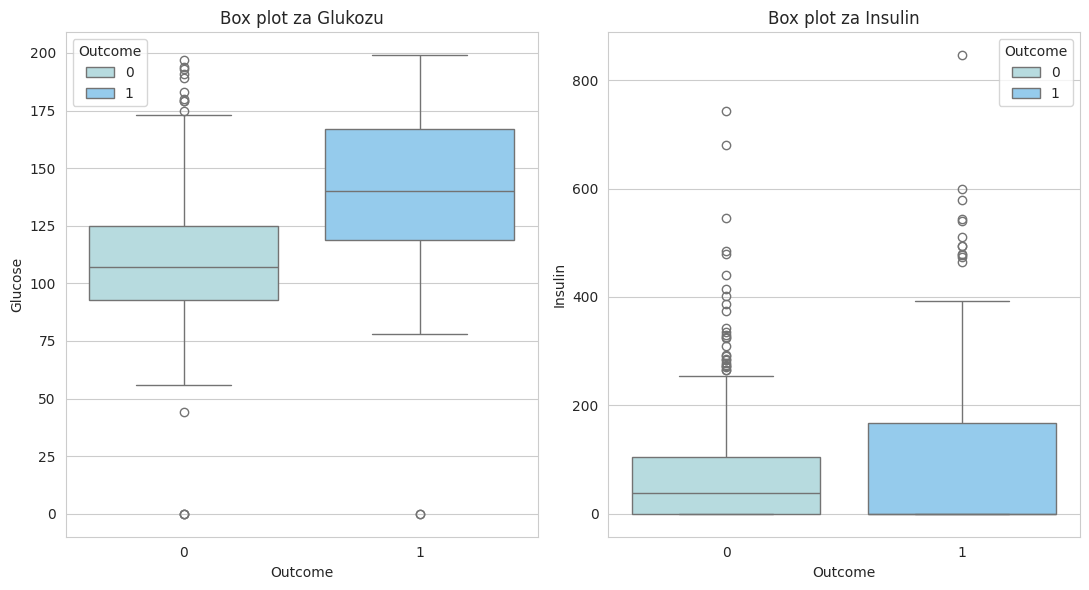

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 6))
Outcome=["Osobe sa dijabetesom", "Osobe bez dijabetesa"]
boje=["powderblue", "lightskyblue"]
sns.boxplot(x='Outcome', y='Glucose', hue="Outcome",  data=df, palette=boje, ax=axs[0])
axs[0].set_title('Box plot za Glukozu')

sns.boxplot(x='Outcome', y='Insulin', data=df, hue="Outcome", palette=boje, ax=axs[1])
axs[1].set_title('Box plot za Insulin')

plt.tight_layout()
plt.show()

Na prvom box-plotu (koji objašnjava kako to razina glukoze u tijelu utiče na dijabetes) možemo primjetiti sljedeće:
Outlier-a na prvom dijelu koji daje informacije o skupini koja ima dijabetes ima  jako malo, što znači da nema mnogo vrijednosti koje se ekstremno razlikuju od ostalih.  Naše vrjednosti podataka se u ovom slučaju uglavnom nalaze unutar granica minimuma i maximuma i malo je onih koji odstupaju od tih granica. Medijana nije tačno na sredini već je malo pomjerena ka manjim vrijednostima, što znači da je vjerovatno više podataka koji  imaju manje razine glukoza ali još je veća šansa da je to zbog malog broja outlier-a.
Što se tiče glukoze kod ispitanika koji ne boluju od dijabetesa, ona ima dosta više outlier-a u odnosu na prethodno istraživanu skupinu. Kao što vidimo dosta je manje ispitanika sa izrazito malom razinom glukoze (ispod 85), postoje outlier-i  u ovom slučaju koji odstupaju od minimalne vrijednosti ali njh je dosta manji broj u odnosu na one koji odstupaju od  maximalne vrijednosti. Mogli bismo zaključiti da osobe koje imaju dijabetes uglabnom imaju visoku razinu glukoze, ali da to ne mora biti pravilo baš zbog outlier-a koje smo prokomentarisali. Oni su ti koji imaju visoku razinu glukoze a nisu dijabetičari. Razlog koji to objašnjava vjerovatno zavisi i od ostalih varijabli koje utiču na dijabetes.


Što se tiče drugog box-plota (koji opisuje vezu dijabetesa i insulina),  prvo što možemo primjetiti jeste nepostojanje granica za minimum. To znači da se naši podaci ne prelaze granicu donjeg kvartila te da je on očigledno i minimalna vrijednost. Ovaj slučaj vrijedi za oba dijela grafa. Maximalna vrijednost za ispitanike koji imaju dijabetes  je 400, ali kao što vidimo imamo outlier-e koji idu čak preko 800. Mada su uglavnom [400-600]. Insulin kod osoba koje nemaju dijabetes ima maximalnu vrijednost negdje oko 300 ali postoje mnogi outlier-i koji imaju vrijednosti nešto manje od 800. Medijana je nešto niže na grafu čak i pored velikog broja outlier-a što znači da imamo mnogo više osoba koje imaju nizak nivo insulina i nemaju dijabetes od onih koji imaju povišen insulin. Možemo također primjetiti da vjerovatno mnogi drugi faktori utiču na to da li će osoba sa ma kakvom razinom insulina imati dijabetes, jer ima dijabetičara i a visokom i sa niskom razinom, a i onih zdravih također.

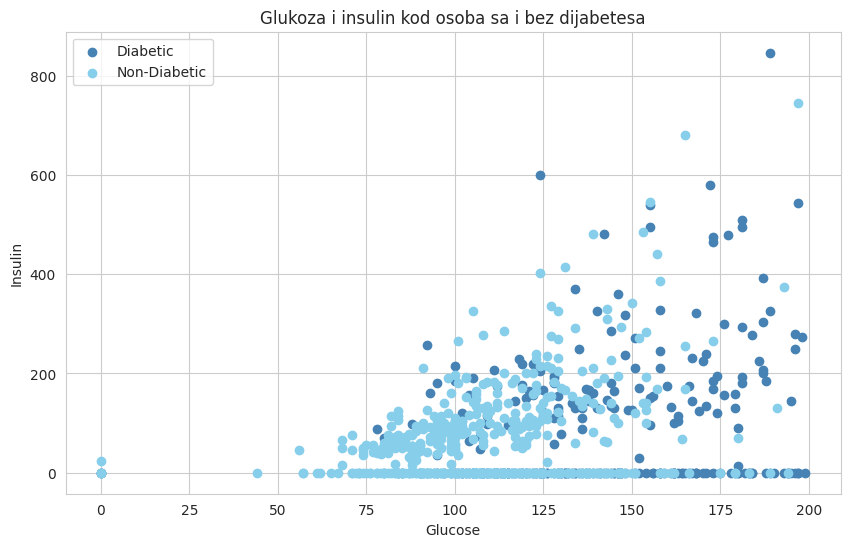

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df['Outcome'] = df['Outcome'].astype(str)

# Filtriranje podataka prema dijabetesu
diabetic = df[df['Outcome'] == '1']
non_diabetic = df[df['Outcome'] == '0']

plt.figure(figsize=(10, 6))
plt.scatter(diabetic['Glucose'], diabetic['Insulin'], color='steelblue', label='Diabetic')
plt.scatter(non_diabetic['Glucose'], non_diabetic['Insulin'], color='skyblue', label='Non-Diabetic')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.title('Glukoza i insulin kod osoba sa i bez dijabetesa')
plt.legend()
plt.show()



Ovim grafom možemo potvrditi da nam razina insulina uglavnom ne daje nikakve informacije o tome da li će ispitanici imati dijabetes ili ne ali da one osobe sa umjerenom razinom glukoze uglavnom nemaju dijabetes (osim pojedinih izuzetaka), a da one koje imaju viši nivo glukoze su također dijabetičari, mada i tu postoje izuzeci.

Sada ćemo grafički prikazati vezu insulina i glukoze.








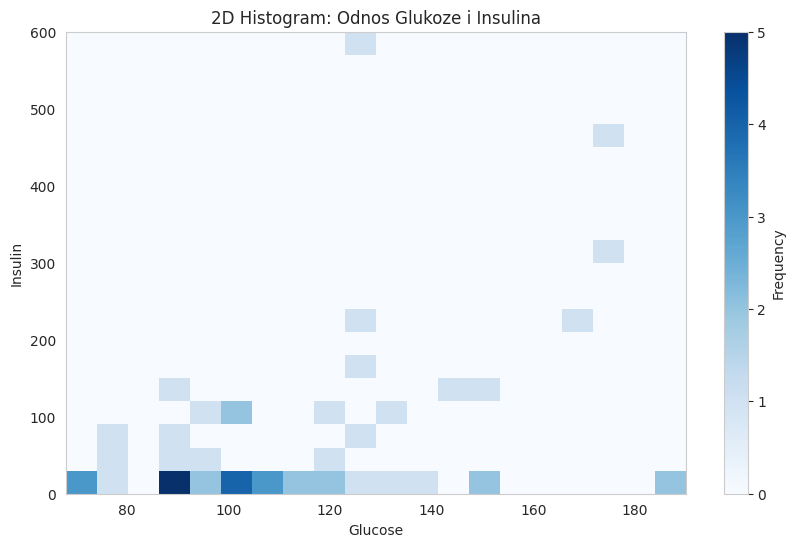

In [ ]:
import matplotlib.pyplot as plt

N = 50
random_sample = df.sample(n=N)

plt.figure(figsize=(10, 6))
plt.hist2d(random_sample['Glucose'], random_sample['Insulin'], bins=20, cmap='Blues')
plt.colorbar(label='Frequency')
plt.title('2D Histogram: Odnos Glukoze i Insulina')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.grid(True)
plt.show()

Na histogramu se vidi da su naše dvije varijable najviše povezane i da se najviše zajedno pojavljuju onda kada je razina glukoze umjerena-visoka, dok razina insulina  poprilično varira u tom slučaju. Najviše su povezani na niskoj razini insulina kada je razina glukoze 75-250. Kada je razina glukoze < 75 naše varijable ili nisu povezane ili naš dataset ne daje dovoljno informacija o toj povezanosti.


Da vidimo i matematički povezanost naših varijabli pomoću kovarijanse.

In [ ]:
covariance=df['Glucose'].cov(df['Insulin'])
print('Kovarijansa između glukoze i insulina je: ', covariance)

Kovarijansa između glukoze i insulina je:  1220.935798973272


U ovom kontekstu, vrijednost kovarijanse ukazuje na to da postoji pozitivna linearna veza između nivoa glukoze i nivoa insulina kod naših podataka. To znači da kada nivo glukoze raste, vjerovatnoća da nivo insulina takođe raste je veća.

Međutim, kovarijansa nije standardizovana mjera i ne daje jasnu informaciju o jačini veze između promenljivih. Sada ćemo izračunati i pogledate Pearsonov koeficijent korelacije između ove dvije promenljive. On će nam dati informaciju o jačini i pravcu linearnog odnosa između njih.


In [ ]:
correlation_factor = df['Glucose'].corr(df['Insulin'])

print("Faktor korelacije između Glukoze i Insulina je:", correlation_factor)

Faktor korelacije između Glukoze i Insulina je: 0.33135710992020934


Faktor korelacije nam govori da ove dvije varijable jesu povezane međusobno, ali da ta povezanost nije velika.

#**Trudnoća i genetska predispozicija za dijabetes**

Tokom trudnoće se javlja novi tip dijabetes, poznat kao **gestacijski tip** dijabetesa koji znatno utiče na dijete koliko i na majku.  

  Razumijevanje faktora rizika i povezanosti između trudnoće i dijabetesa ključno je za identifikaciju trudnica koje su izložene većem riziku od razvoja ove komplikacije tokom trudnoće. Genetska predispozicija igra važnu ulogu u razvoju gestacijskog dijabetesa, zajedno s drugim faktorima rizika kao što su pretilost, nedostatak tjelesne aktivnosti, dob i povijest trudnoće.

U ovoj analizi želimo istražiti utjecaj genetske predispozicije na gestacijski dijabetes tokom trudnoće i općenito pojedinačne relacije između dijabetesa i ovih faktora. Koristit ćemo se informacijama iz datog dateset-a da bismo otkrili povezanost između ova tri elementa


In [ ]:
#STANDARDNA DEVIJACIJA, VARIJANSA, MEDIJAN I SREDNJA VRIJEDNOST ZA TRUDNOĆU
print('Srednja vrijednost za trudnoću:', df['Pregnancies'].mean())
print('Standardna devijacija za trudnoću:',df['Pregnancies'].std())
print('Medijan za trudnoću:', df['Pregnancies'].median())
print('Varijansa za trudnoću:', df['Pregnancies'].var())


Srednja vrijednost za trudnoću: 3.8450520833333335
Standardna devijacija za trudnoću: 3.3695780626988694
Medijan za trudnoću: 3.0
Varijansa za trudnoću: 11.354056320621465


In [ ]:
df['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [ ]:
#STANDARDNA DEVIJACIJA, VARIJANSA, MEDIJAN I SREDNJA VRIJEDNOST ZA GENETIČKU PREDISPOZICIJU
print('Srednja vrijednost za genetičku predispoziciju:', df['DiabetesPedigreeFunction'].mean())
print('Standardna devijacija za genetičku predispoziciju:',df['DiabetesPedigreeFunction'].std())
print('Medijan za genetičku predispoziciju:', df['DiabetesPedigreeFunction'].median())
print('Varijansa za genetičku predispoziciju:', df['DiabetesPedigreeFunction'].var())


Srednja vrijednost za genetičku predispoziciju: 0.47187630208333325
Standardna devijacija za genetičku predispoziciju: 0.3313285950127749
Medijan za genetičku predispoziciju: 0.3725
Varijansa za genetičku predispoziciju: 0.1097786378731394


In [ ]:
df['DiabetesPedigreeFunction'].describe()

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

In [ ]:
hist, bins = np.histogram(df['Pregnancies'], bins='auto')
weighted_mean_pregnancies=np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost trudnoću:', weighted_mean_pregnancies)

Očekivana vrijednost trudnoću: 3.175048828125


In [ ]:
hist, bins = np.histogram(df['DiabetesPedigreeFunction'], bins='auto')
weighted_mean_diabetespedigreefunction=np.average(bins[:-1], weights = hist)
print('Očekivana vrijednost genetsku predispoziciju:', weighted_mean_diabetespedigreefunction)

Očekivana vrijednost genetsku predispoziciju: 0.4328962823275862


Srednja vrijednost za dijabetes u trudnoći je 3.84 dok je očekivana vrijednost 3.17, a za genetsku predispoziciju je srednja vrijednost je 0.47 i očekivana vrijednost 0.42. Iz ovoga možemo vidjeti da su njihove vrijednosti blizu jedna drugoj. Kada su očekivana vrijednost i srednja vrijednost gotovo iste, to znači da je distribucija podataka gotovo simetrična i da nema znatne asimetrije ili neravnoteže u podacima.

Ovo nam može ukazivati da će rezultat biti poželjan i da su podaci relativno stabilni i predvidljivi, što olakšava njihovu analizu i tumačenje. Međutim, provjerit ćemo i  druge statističke mjere i grafikone da bismo bolje razumjeli distribuciju podataka i bili sigurni da je naša interpretacija ispravna.

**Analiza distribucije za pojedine varijable - trudnoća i genetička predispozicija**

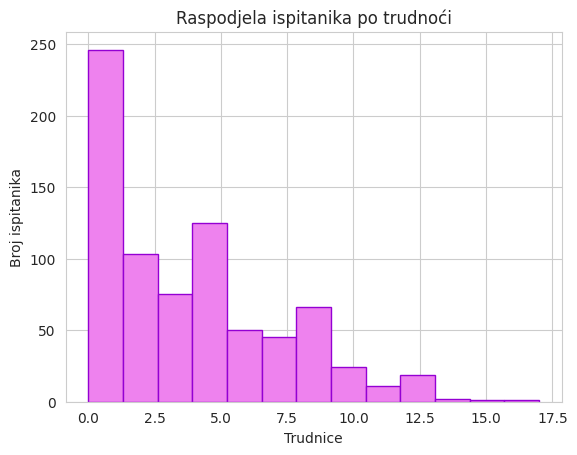

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Pregnancies'], bins=13, color='violet', edgecolor='darkviolet')
plt.xlabel('Trudnice')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela ispitanika po trudnoći')
plt.show()

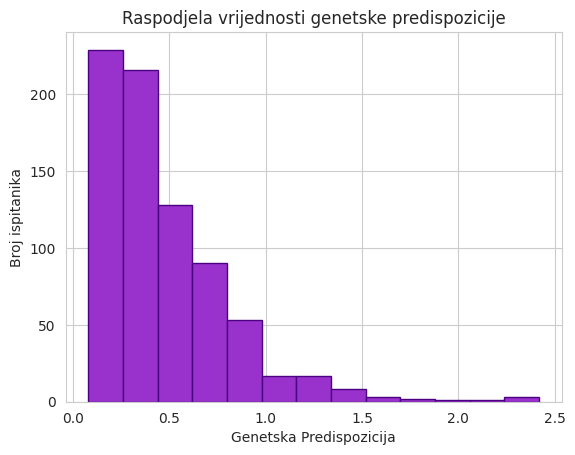

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['DiabetesPedigreeFunction'], bins=13, color='darkorchid', edgecolor='indigo')
plt.xlabel('Genetska Predispozicija')
plt.ylabel('Broj ispitanika')
plt.title('Raspodjela vrijednosti genetske predispozicije')
plt.show()

Sa data dva histograma možemo vidjeti da se najviši segmenti na histogramu, odnosno mode, nalaze na lijevoj strani, što ukazuje na to da su najčešće vrijednosti skoncentrirane prema nižim vrijednostima. Niti jedne od ovih vrijednosti na histogramu nisu simetrične, ali možemo primjetiti kako se njihove vrijednosti kreću linearno.

**Faktori korelacije i kovarijanse**

In [ ]:
correlation=df['DiabetesPedigreeFunction'].corr(df['Pregnancies'])
print('Faktor korelacije između trudnoće i genetske predispozicije: ', correlation)

Faktor korelacije između trudnoće i genetske predispozicije:  -0.03352267296261302


In [ ]:
covariance=df['Pregnancies'].cov(df['DiabetesPedigreeFunction'])
print('Kovarijansa trudnoće i genetske predispozicije: ', covariance)

Kovarijansa trudnoće i genetske predispozicije:  -0.03742597138472396


Iz datog proračuna korelacije i kovarijanse između trudnoće i genetske predispozicije vidimo da je oba računa negativna što znači da ova dva elementa se kreću u suprtonom smjeru i da ne utiču jedan na drugi. Zbog jako malih vrijednosti one nemaju jaku linearnu vezu niti imamo direktan uzročan odnos između njih. Ovo ćemo pokazati koristeći scatter-plot.

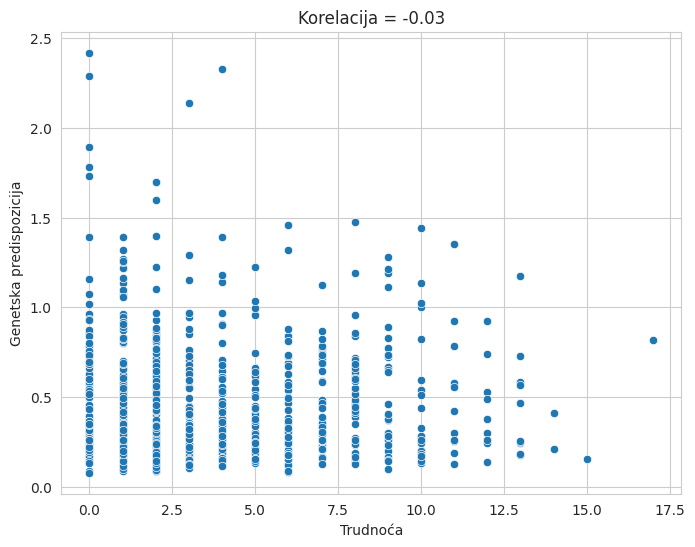

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

korelacija = df['Pregnancies'].corr(df['DiabetesPedigreeFunction'])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Pregnancies', y='DiabetesPedigreeFunction', data=df)
plt.title(f'Korelacija = {korelacija:.2f}')
plt.xlabel('Trudnoća')
plt.ylabel('Genetska predispozicija')
plt.grid(True)
plt.show()

Većina vrijednosti je linearno vertikalna, što naznačava snažnu vezu između varijabli, ali samo u vertikalnom smjeru. Gusta grupiranja linija mogu ukazivati na homogenost, što može implicirati da genetička predispozicija za određene metaboličke poremećaje, poput dijabetesa tipa 2, može povećati rizik od razvoja ovog stanja kod žena tijekom trudnoće.








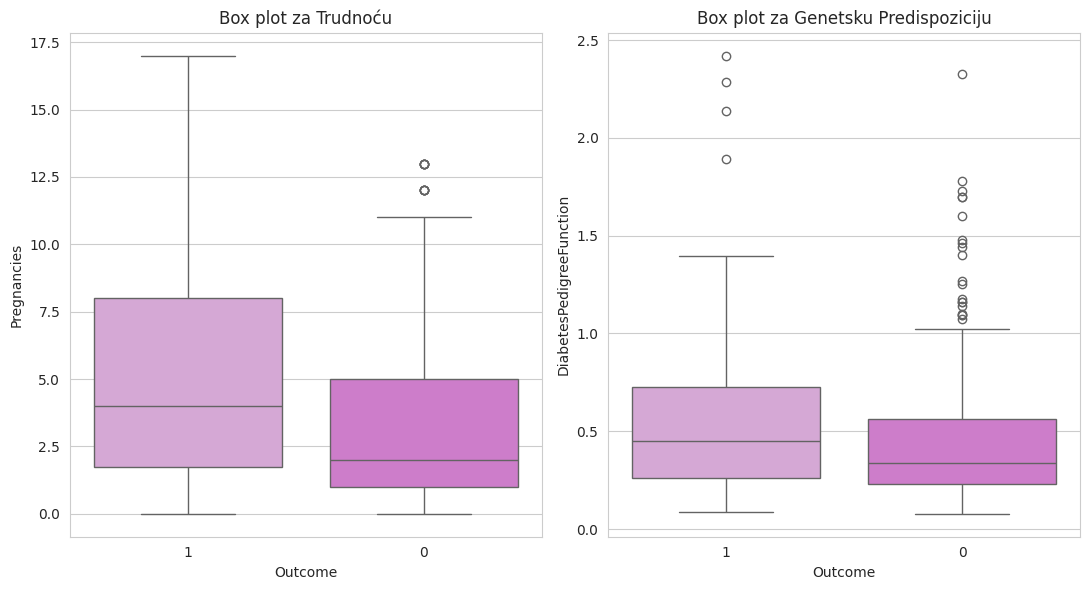

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 6))
Outcome=["Osobe sa dijabetesom", "Osobe bez dijabetesa"]
boje=["#DDA0DD", "#DA70D6"]
sns.boxplot(x='Outcome', y='Pregnancies', hue="Outcome",  data=df, palette=boje, ax=axs[0])
axs[0].set_title('Box plot za Trudnoću')

sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, hue="Outcome", palette=boje, ax=axs[1])
axs[1].set_title('Box plot za Genetsku Predispoziciju')

plt.tight_layout()
plt.show()

Prvi box plot koji prikazuje trudnice sa dijabetesom, nema outlinera što ukazuje na to da nemamo ekstremnih varijacija te je u domenu svog minimuma i maksimuma mada je bliže svom minimumu. Dok trudnice bez dijabetesa imaju mnogo manji maksimum u odnosu na trudnice sa dijabetesom.  Ovo može ukazivati na razlike u riziku od dijabetesa među različitim skupinama, pri čemu trudnice bez dijabetesa možda imaju stabilniju i manju varijabilnost u genetskim faktorima koji su povezani s dijabetesom. Medijana u oba slučaja nam je pomaknuta prema donjoj granici iz čega zaključujemo  da vrijednosti nisu jednako raspoređene i da je veći dio podataka koncentriran na višim vrijednostima, dok su niže vrijednosti manje učestale. Na ovo implicira i pozicija box plota čija je donja linija (whisker) kraća od gornje. Interkvartilni rang trudnica bez dijabetesa je manji od interkvartilnog ranga trudnica sa dijabetesom što ukazuje na manju varijabilnost podataka kod trudnica bez dijabetesa. Ove implikacije naglašavaju važnost analize razlika u varijabilnosti između skupina kako bi se bolje razumjele karakteristike trudnoće i potrebe za prilagođenim medicinskim intervencijama. Na primjer, veća varijabilnost može sugerirati veći opseg ili heterogenost u podacima, dok manja varijabilnost može sugerirati homogeniju skupinu ili manju rasprostranjenost vrijednosti.

Na box plotu Genetske Predispozicije u oba slučaja možemo vidjeti da imamo dosta outlinera koje su veće od maksimuma. Ovo može ukazivati na ekstremne vrijednosti ili varijacije u genetskim faktorima koji su bitni za razumijevanje dijabetesa.

U sva četiri slučaja imamo pozitivnu asimetriju.


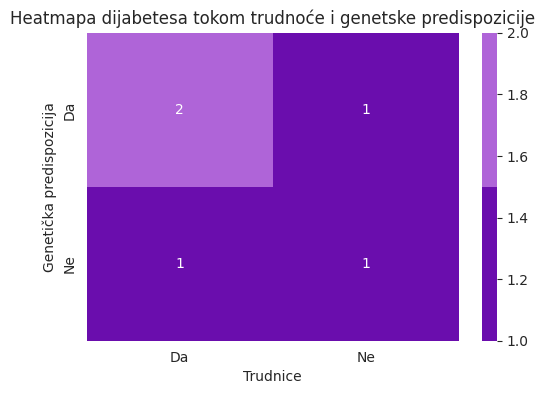

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'DiabetesPedigreeFunction': ['Da', 'Da', 'Ne', 'Ne', 'Da'],
    'Pregnancies': ['Da', 'Ne', 'Ne', 'Da', 'Da']
}

df = pd.DataFrame(data)

heatmap_data = pd.crosstab(df['DiabetesPedigreeFunction'], df['Pregnancies'])

my_palette = sns.color_palette(['#6a0dad', '#af64d8'])

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, cmap=my_palette, fmt="d")


plt.title('Heatmapa dijabetesa tokom trudnoće i genetske predispozicije')
plt.xlabel('Trudnice')
plt.ylabel('Genetička predispozicija')
plt.show()


Na ovom heatmapu, 1 i 2 su vrijednosti koje imamo ( odnosno dijabetes i bez dijabetesa ). Vidimo da se ove vrijednosti preklapaju, odnosno da većina ispitanika koje su trudnice i koje imaju genetsku predispoziciju imaju dijabetes, no ovo nam ne ukazuje na moguću relaciju između ova dva elementa.

# **Starosna dob i krvni pritisak u korelaciji sa dijabetesom**

Nakon analize skupa podataka o glukozi, insulinu, tjelesnoj težini i starosnoj dobi ispitanika, sada je potrebno istražiti kako su ove varijable povezane s dijabetesom. Prije samog istraživanja postavljena su određena očekivanja.

1. Povezanost između starosti i dijabetesa: Starost je jedan od ključnih faktora rizika za razvoj dijabetesa tipa 2. S godinama, tijelo postaje manje osjetljivo na insulin, hormon koji regulira razinu šećera u krvi, što može dovesti do dijabetesa tipa 2. Dakle, što je osoba starija, to je veći rizik od razvoja dijabetesa.
2. Povezanost između starosti i krvnog pritiska: Krvni pritisak također ima tendenciju rasti s godinama. Starenjem, arterije gube elastičnost, što može rezultirati povišenjem krvnog pritiska. Visok krvni pritisak (hipertenzija) je čest kod starijih osoba.
3. Povezanost između krvnog pritiska i dijabetesa: Dijabetes može povećati rizik od visokog krvnog pritiska. Visoke razine glukoze u krvi mogu oštetiti krvne sudove i srce, što povećava rizik od hipertenzije. Također, dijabetes je čest faktor rizika za razvoj drugih kardiovaskularnih bolesti, što može utjecati na krvni pritisak.
*Naredno istraživanje će nam pomoći bolje razumjeti kako starost, krvni pritisak i dijabetes međusobno utječu te kako ove varijable mogu biti važne u prevenciji i upravljanju dijabetesom i kardiovaskularnim bolestima.*

In [ ]:
# Opća ispitivanja vezanja za krvni pritisak
print('Srednja vrijednost za krvni pritisak:', df['BloodPressure'].mean())
print('Standardna devijacija za krvni pritisak:',df['BloodPressure'].std())
print('Medijan za krvni pritisak:', df['BloodPressure'].median())
print('Varijansa za krvni pritisak:', df['BloodPressure'].var())

Srednja vrijednost za krvni pritisak: 69.10546875
Standardna devijacija za krvni pritisak: 19.355807170644777
Medijan za krvni pritisak: 72.0
Varijansa za krvni pritisak: 374.6472712271838


In [ ]:
# Opća ispitivanja vezana za starosnu dob
print('Srednja vrijednost za starosnu dob:', df['Age'].mean())
print('Standardna devijacija za starosnu dob:',df['Age'].std())
print('Medijan za starosnu dob: ', df['Age'].median())
print('Varijansa za starosnu dob:', df['Age'].var())

Srednja vrijednost za starosnu dob: 33.240885416666664
Standardna devijacija za starosnu dob: 11.760231540678685
Medijan za starosnu dob:  29.0
Varijansa za starosnu dob: 138.30304589037377


**Povezanost starosne dobi i krvnog pritiska**

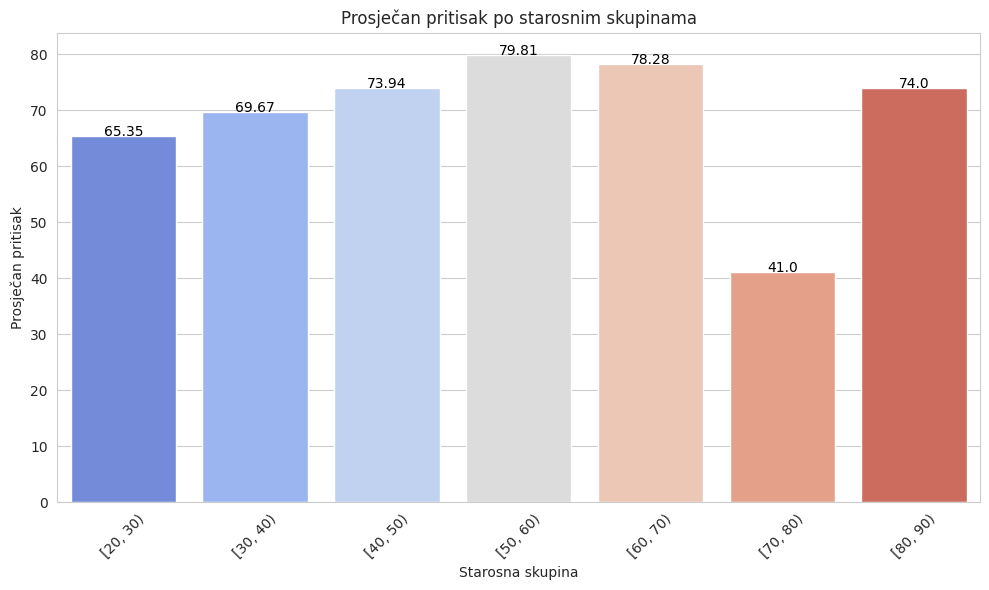

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'Age' and 'BloodPressure' are columns
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 80, 90], right=False)

# Group by age groups
grouped = df.groupby('AgeGroup', dropna=False)
average_bloodpressure = grouped['BloodPressure'].mean().reset_index()

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a bar plot
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='AgeGroup', y='BloodPressure', hue='AgeGroup', data=average_bloodpressure, palette='coolwarm', dodge=False)

# Add labels and title
barplot.set_title('Prosječan pritisak po starosnim skupinama')
barplot.set_xlabel('Starosna skupina')
barplot.set_ylabel('Prosječan pritisak')

# Set tick positions and labels for x-axis
barplot.set_xticks(range(len(average_bloodpressure)))
barplot.set_xticklabels(average_bloodpressure['AgeGroup'].astype(str), rotation=45)

# Add value labels on each bar
for index, row in average_bloodpressure.iterrows():
    barplot.text(row.name, row.BloodPressure, round(row.BloodPressure, 2), color='black', ha="center")

plt.legend([], [], frameon=False)  # Remove legend
plt.tight_layout()
plt.show()





Ovaj bar plot prikazuje prosječan krvni pritisak prema dobnoj skupini, uključujući sve dobne skupine čak i ako u nekim skupinama nema podataka. Na taj način, imat ćemo cjelovit prikaz distribucije krvnog tlaka prema dobnoj skupini. Na osnovu dobivenih rezultata vidimo da sa povećanjem starosne dobi povećava se i krvni pritisak. Kriticnoj skupini pripadaju dvije starosne grupe tačnije ispitanici od 50 do 70 godina.

**Detaljan opis istraživanih varijabli**

In [ ]:
df['BloodPressure'].describe()

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [ ]:
df['Age'].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

**Starosne skupine koje ispitujemo i broj ispitanika**

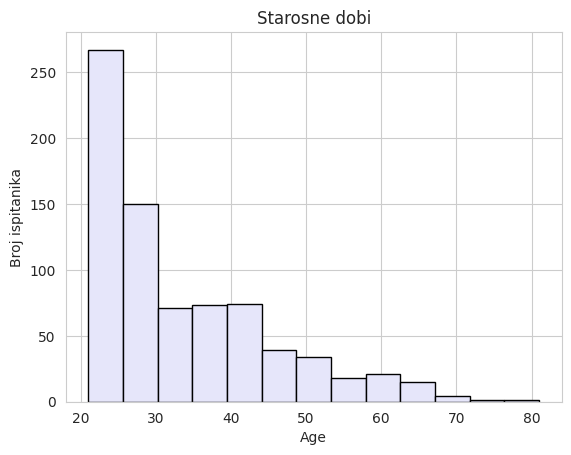

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=13, color='lavender', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Broj ispitanika')
plt.title('Starosne dobi')
plt.show()

*Komentar: Ovaj bar plot nam je veoma bitan iz razloga što u sljedećim istraživanjima možemo uvezati zašto imamo tako mala očitanja pri starosnim skupinama od 70 do 90 godina. Iz priloženog razlog tome je mali broj ispitanika.*

**Tri varijable i njihova zavisnost na histogramu**

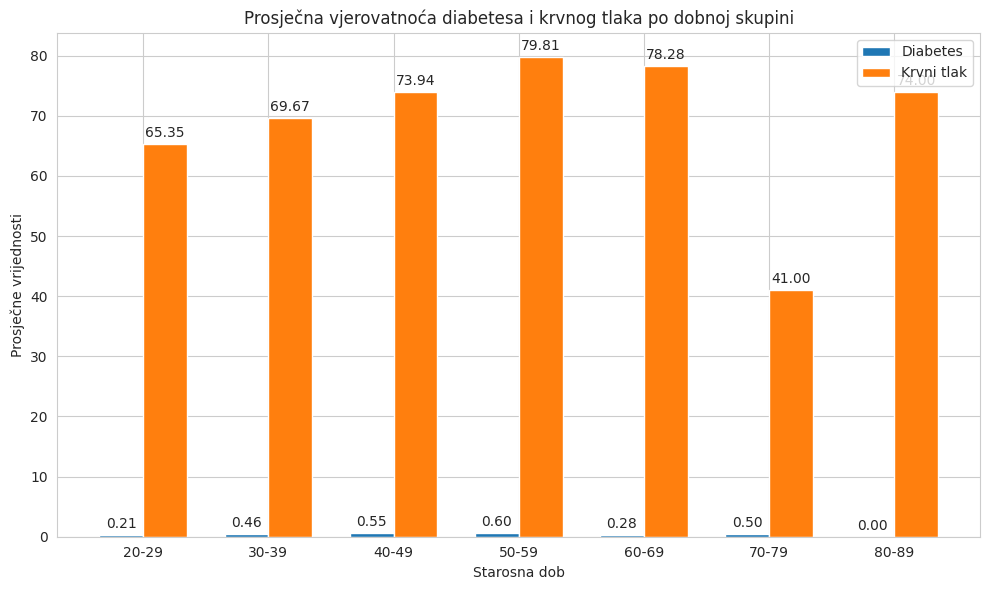

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Provjerite DataFrame
df.head()

# Podjela prema dobi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Računanje prosječnih vrijednosti
age_groups = df.groupby('AgeGroup')

mean_diabetes = age_groups['Outcome'].mean()
mean_blood_pressure = age_groups['BloodPressure'].mean()

# Prikazivanje podataka
fig, ax = plt.subplots(figsize=(10, 6))

# Postavljanje položaja traka
bar_width = 0.35
index = range(len(labels))

# Prikazivanje Diabetesa
rects1 = ax.bar(index, mean_diabetes, bar_width, label='Diabetes')

# Prikazivanje Krvnog tlaka
rects2 = ax.bar([i + bar_width for i in index], mean_blood_pressure, bar_width, label='Krvni tlak')

# Dodavanje oznaka i naslova
ax.set_xlabel('Starosna dob')
ax.set_ylabel('Prosječne vrijednosti')
ax.set_title('Prosječna vjerovatnoća diabetesa i krvnog tlaka po dobnoj skupini')
ax.set_xticks([i + bar_width/2 for i in index])
ax.set_xticklabels(labels)
ax.legend()

# Dodavanje vrijednosti na vrhove traka
def autolabel(rects):
    """Dodavanje vrijednosti na vrhove traka."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()






Prvenstveno, podaci se grupiraju prema dobnoj skupini, omogućujući nam razumijevanje kako se zdravstveni parametri mijenjaju s godinama. Ova podjela omogućuje jasnu vizualizaciju kako se zdravlje mijenja od mladosti do starije dobi. Grafikon koji se generira prikazuje prosječne vrijednosti dijabetesa i krvnog tlaka za svaku dobnu skupinu. Kroz ovaj grafikon, lako možemo usporediti kako se ovi zdravstveni pokazatelji mijenjaju s godinama. Oznake na grafikonu jasno označavaju dobne skupine na x-osi i prosječne vrijednosti na y-osi, što olakšava interpretaciju rezultata. Dodatno, dodane su i vrijednosti na vrhove traka kako bismo imali konkretnije brojčane podatke.

---
X-osa grafika prikazuje starosne grupe. Počinje od 20-29 godina i ide do 80-89 godina. Y-osa prikazuje vjerovatnoću. Počinje od 0 i ide do 80%.

Dvije linije na grafikonu predstavljaju dijabetes i visoki krvni pritisak. Plava linija predstavlja dijabetes. Zelena linija predstavlja visoki krvni pritisak.

Prema grafu, vjerovatnoća obolijevanja od dijabetesa i visokog krvnog pritiska raste sa godinama. Na primjer, vjerovatnoća obolijevanja od dijabetesa je oko 0.21% za ljude između 20 i 29 godina. Ali raste na 79.81% za ljude između 80 i 89 godina.

Vjerovatnoća obolijevanja od visokog krvnog pritiska je također veća kod starijih ljudi nego kod mlađih. Na primjer, vjerovatnoća obolijevanja od visokog krvnog pritiska je oko 0.46% za ljude između 20 i 29 godina. Ali raste na 50% za ljude između 80 i 89 godina.

Važno je napomenuti da ovaj grafikon prikazuje samo prosječnu vjerovatnoću obolijevanja od dijabetesa i visokog krvnog pritiska. To znači da će neki ljudi u svakoj starosnoj grupi imati veću ili manju vjerovatnoću obolijevanja od ovih stanja.


---



Osim toga, možemo primijetiti da dobna skupina od 50 do 59 godina pokazuje najviše prosječne vrijednosti krvnog tlaka i dijabetesa. Ova dobna skupina često se smatra prijelaznim razdobljem između srednje dobi i starije dobi te je obično povezana s većim rizikom od razvoja kardiovaskularnih bolesti i metaboličkih poremećaja.

Ovo otkriće sugerira da su osobe u dobi od 50 do 59 godina podložnije visokom krvnom tlaku i dijabetesu u usporedbi s drugim dobima. To može biti posljedica fizioloških promjena koje se događaju tijekom srednje životne dobi, uključujući smanjenje tjelesne aktivnosti, promjene u prehrambenim navikama i povećanje stresa.
S druge strane, mlade osobe (20-29 i 30-39 godina) pokazuju niže prosječne vrijednosti krvnog tlaka i dijabetesa. To sugerira da su mlađi pojedinci manje podložni ovim zdravstvenim problemima, što može biti rezultat veće tjelesne aktivnosti, zdravijih prehrambenih navika i općenito boljeg zdravstvenog stanja u mladosti.

Ovi podaci ističu važnost prevencije i ranog otkrivanja zdravstvenih problema, posebno u dobi od 50 do 59 godina. Rano prepoznavanje i intervencija mogu smanjiti rizik od komplikacija i poboljšati kvalitetu života u ovom ključnom razdoblju.

**Komparacija ispitanika sa ili bez dijabetesa i krvnog pritiska putem violinskog dijagrama**

<Axes: xlabel='Outcome', ylabel='BloodPressure'>

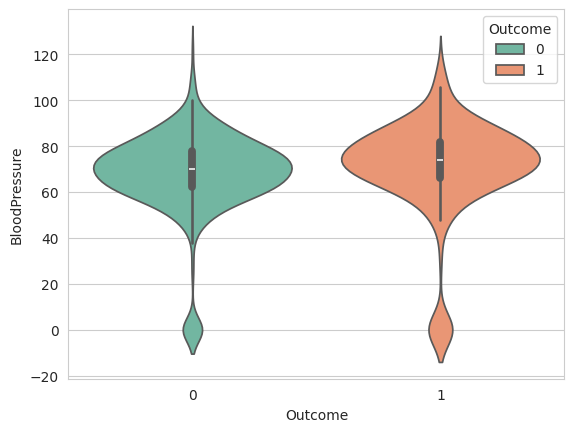

In [ ]:
sns.violinplot(x='Outcome', y='BloodPressure', data=df, hue='Outcome', palette='Set2')


Istraživanjem smo došle do još jednog odličnog načina za očitanje vrijednosti podataka. Naime, putem violinskog dijagrama mozemo lako uvidjeti blagu povećanost srednje vrijednosti između osoba sa i bez dijabetesa. Iako je ispitanika bez dijabetesa manje ovo je odličan pokazatelj da bez obzira na te podatke opet dijabetes zaista zavisi od krvnog pritiska. Treba skrenuti pažnju na minimalne i maksimalne vrijednosti.

**Faktori korelacije i kovarijanse**

 U ovom slučaju, faktor korelacije od 0.24 sugerira da postoji umjerena, ali pozitivna korelacija između godina i krvnog pritiska. To znači da se, u prosjeku, krvni pritisak povećava s godinama, ali ta povezanost nije toliko jaka.

In [ ]:
covariance=df['BloodPressure'].cov(df['Age'])
print('Kovarijansa krvnog pritiska i starosne dobi: ', covariance)

Kovarijansa krvnog pritiska i starosne dobi:  54.52345277868317


In [ ]:
correlation=df['Age'].corr(df['BloodPressure'])
print('Faktor korelacije između krvnog pritiska i godina: ', correlation)

Faktor korelacije između krvnog pritiska i godina:  0.23952794642136366


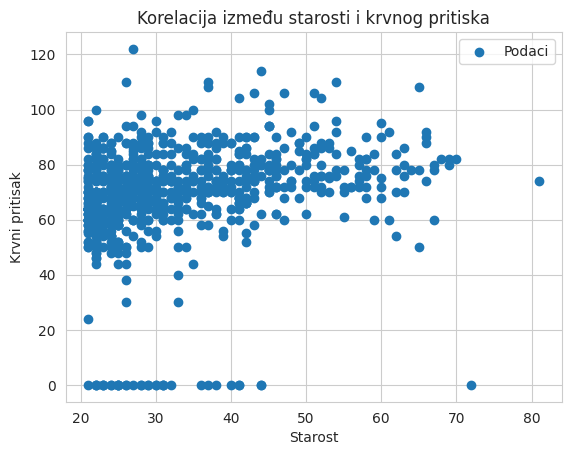

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Izračunajte korelaciju
correlation = df['Age'].corr(df['BloodPressure'])

# Prikazujemo podatke
plt.scatter(df['Age'], df['BloodPressure'], label='Podaci')



# Dodajemo oznake osi i naslov
plt.xlabel('Starost')
plt.ylabel('Krvni pritisak')
plt.title('Korelacija između starosti i krvnog pritiska')

# Prikazujemo grafikon
plt.legend()
plt.show()


U praksi, ovo znači da starije osobe imaju tendenciju da imaju nešto više krvni pritisak u odnosu na mlađe osobe, ali ovaj faktor nije dovoljno jak da bi se mogao koristiti kao pouzdan prediktor krvnog pritiska na temelju dobi. Pored toga imamo također dosta podata oko nule što bi označavalo da su vjerovatno pojedine vrijednosti u dataset-u dodijeljene sa vrijednosti nula.

**Poveznica debljine kože i krvonog pritiska, da li je ima smisla ispitivati?**


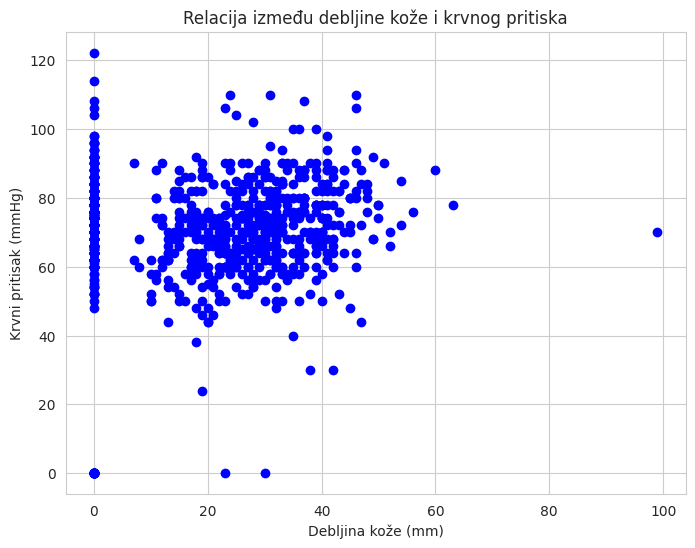

In [ ]:
import matplotlib.pyplot as plt

# Sada možemo nacrtati dot plot
plt.figure(figsize=(8, 6))
plt.scatter(df['SkinThickness'], df['BloodPressure'], color='blue')
plt.title('Relacija između debljine kože i krvnog pritiska')
plt.xlabel('Debljina kože (mm)')
plt.ylabel('Krvni pritisak (mmHg)')
plt.grid(True)
plt.show()

Analiza podataka

Dot dijagram pokazuje da postoji pozitivna korelacija između debljine kože i krvnog tlaka. To znači da što je debljina kože veća, to je i krvni tlak veći. Ova korelacija nije savršena, jer postoje neke tačke koje se odvajaju od općeg trenda.

Objašnjenje korelacije

Postoji nekoliko mogućih objašnjenja pozitivne korelacije između debljine kože i krvnog tlaka. Jedno od mogućih objašnjenja je da debljina kože odražava količinu masnog tkiva u tijelu. Masno tkivo proizvodi hormone koji mogu povisiti krvni tlak. Drugo moguće objašnjenje je da debljina kože i krvni tlak imaju zajednički uzrok, kao što je genetika ili životni stil.

Zaključak

Podaci na slici pokazuju da postoji pozitivna korelacija između debljine kože i krvnog tlaka. Ova korelacija nije savršena, ali je statistički značajna. Na kraju ovog poglavlja može se reci da su dijabetes, krvni pritisak i starosna dob u pozitivnoj korelaciji te da posebno treba obratiti pažnju na ispitanike sa ovim simptomima.

# **Zaključak: Da li ispitane kategorije i njihove međusobne relacije imaju poveznicu sa dijabetesom?**


Sada kada smo detaljno istražili veze između različitih faktora koji utiču na dijabetes, postavile smo nekoliko hipoteza koje želimo dodatno istražiti i potvrditi. Nadalje, želimo dodatno produbiti naše razumijevanje o dijabetesu. Kako bismo to postigli, želimo obogatiti našu analizu sljedećim pitanjima.

# **HIPOTEZA : Ispitanici u starosnoj skupini između 50 i 60 godina imaju najveću vjerovatnoću za oboljenjem od dijabetesa.**

U ovom dijelu ćemo detaljno analizirati faktore koji doprinose povećanom riziku od dijabetesa u dobnoj skupini od 50 do 60 godina. Nadamo se da će rezultati ovog istraživanja pružiti temelj za razvoj ciljanih strategija prevencije i liječenja, te da ćemo potvriditi našu hipotezu.
Ova dobna skupina je ključna za istraživanje dijabetesa iz nekoliko razloga:

1. Zdravstveni utjecaj: Dijabetes ima značajan utjecaj na zdravlje i kvalitetu života u ovoj dobnoj skupini. Komplikacije kao što su srčane bolesti, oštećenje vida i neurološki problemi mogu biti posebno ozbiljne u ovoj životnoj dobi.
2. Povećan rizik: Osobe u dobi između 50 i 60 godina izložene su većem riziku od razvoja dijabetesa zbog kombinacije faktora kao što su genetska predispozicija, promjene u načinu života i hormonalne promjene.
3. Značaj ranog otkrivanja: Otkrivanje dijabetesa u ranim fazama može značajno poboljšati prognozu i smanjiti rizik od komplikacija. Stoga je važno istražiti metode ranog otkrivanja i intervencije koje su specifično usmjerene na ovu dobnu skupinu.

Provjerit ćemo vjerojatnosti oboljenja od dijabetesa u svakoj od naših zadanih starosnih grupa kako bismo utvrdili koja od njih ima najveću vjerojatnost. Na temelju dobivenih rezultata moći ćemo donijeti zaključke.

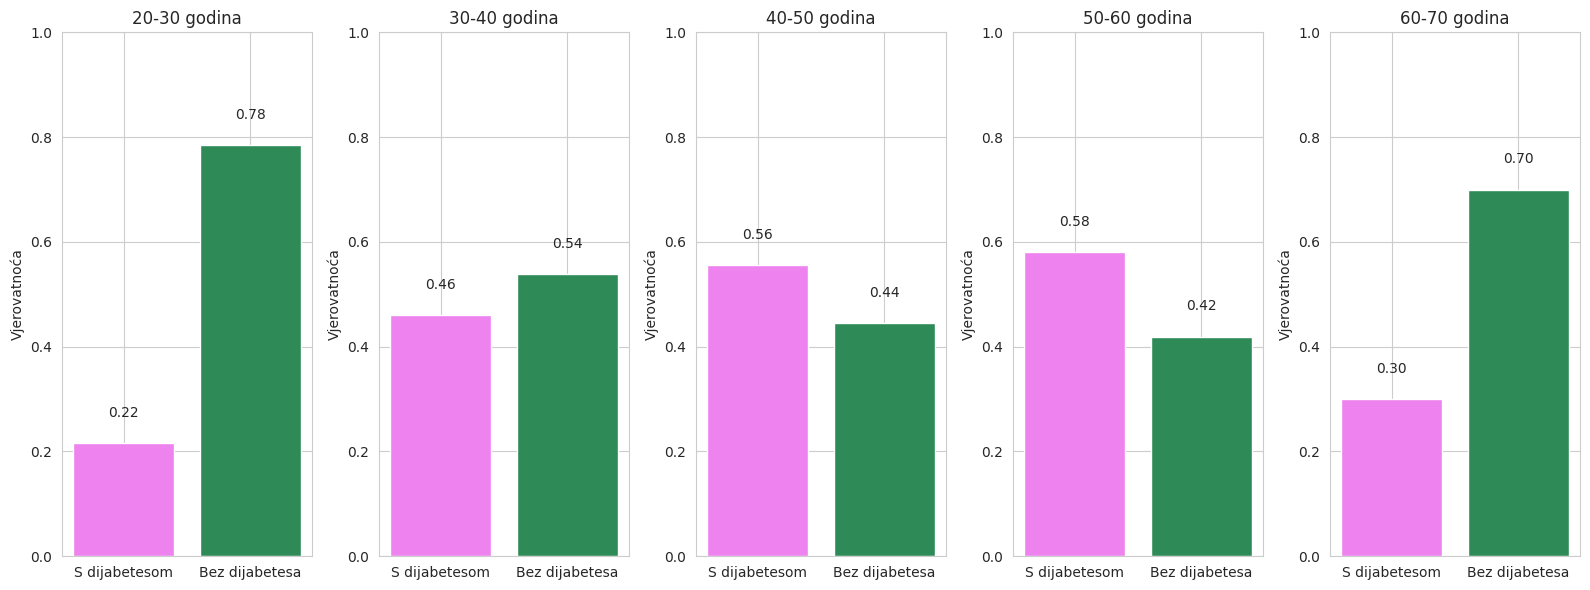

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_diabetes_probability(data, age_group):
    filtered_data = data[(data['Age'] >= age_group[0]) & (data['Age'] <= age_group[1])]
    diabetes_count = filtered_data[filtered_data['Outcome'] == 1]['Outcome'].count()
    no_diabetes_count = filtered_data[filtered_data['Outcome'] == 0]['Outcome'].count()
    total_count = len(filtered_data)
    diabetes_probability = diabetes_count / total_count
    no_diabetes_probability = no_diabetes_count / total_count
    return diabetes_probability, no_diabetes_probability

age_groups = [(20, 30), (30, 40), (40, 50), (50, 60), (60, 70)]

fig, axes = plt.subplots(ncols=len(age_groups), figsize=(16, 6))

for i, age_group in enumerate(age_groups, start=0):
    diabetes_probability, no_diabetes_probability = calculate_diabetes_probability(df, age_group)

    ax = axes[i]

    ax.bar(['S dijabetesom', 'Bez dijabetesa'], [diabetes_probability, no_diabetes_probability], color=['violet', 'seagreen'])
    ax.set_title(f'{age_group[0]}-{age_group[1]} godina')
    ax.set_ylabel('Vjerovatnoća')
    ax.set_ylim(0, 1)

    ax.text(0, diabetes_probability + 0.05, f'{diabetes_probability:.2f}', ha='center')
    ax.text(1, no_diabetes_probability + 0.05, f'{no_diabetes_probability:.2f}', ha='center')

plt.tight_layout()
plt.show()

Nakon istraživanja, možemo donijeti nekoliko zaključaka:

1. Ispitanici koji su mlađi od 30 godina i stariji od 60 godina imaju najmanje šanse za oboljenjem od dijabetesa u usporedbi s ostalim starosnim grupama. Ovo sugerira da su mlađe i starije dobne skupine manje izložene riziku od dijabetesa.
2. Među svim starosnim grupama, najveća vjerojatnost za oboljenjem od dijabetesa pripada ispitanicima u dobi od 50 do 60 godina. Ovo potvrđuje našu hipotezu o povezanosti te dobne skupine s većim rizikom od dijabetesa.

Ovi zaključci pružaju važne uvide u profil rizika za dijabetes prema dobi, što može biti od koristi u planiranju preventivnih mjera i intervencija usmjerenih na smanjenje prevalencije dijabetesa.
Također moramo napomenuti da imamo znatno manji broj ispitanika u starosnim skupinama iznad 60 godina.


**Faktori uticaja na ciljanu skupinu ispitanika**

Prije nego započnemo detaljnija istraživanja utjecaja drugih faktora na ovu dobnu skupinu, prvo je potrebno provjeriti koliko zapravo imamo ispitanika u dobi od 50 do 60 godina koji imaju dijabetes. Ovaj korak je ključan kako bismo dobili jasniju sliku o prevalenciji dijabetesa u toj specifičnoj dobnoj skupini.

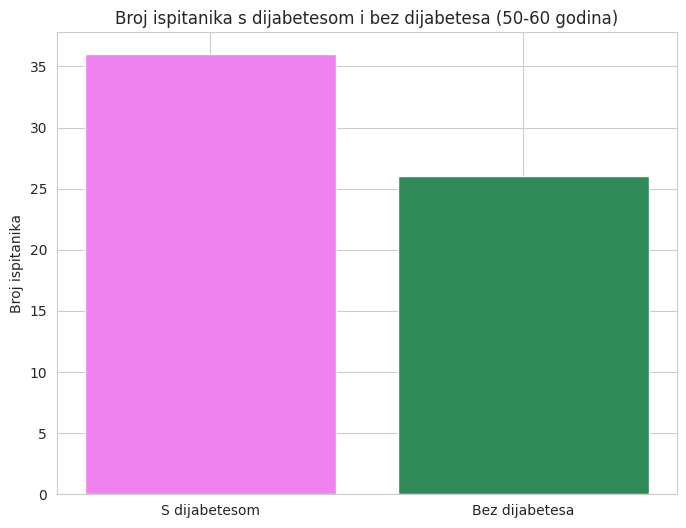

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

filtered_data = df[(df['Age'] >= 50) & (df['Age'] <= 60)]

diabetes_count = filtered_data[filtered_data['Outcome'] == 1]['Outcome'].count()
no_diabetes_count = filtered_data[filtered_data['Outcome'] == 0]['Outcome'].count()

# Vizualizacija rezultata
labels = ['S dijabetesom', 'Bez dijabetesa']
counts = [diabetes_count, no_diabetes_count]

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['violet', 'seagreen'])
plt.title('Broj ispitanika s dijabetesom i bez dijabetesa (50-60 godina)')
plt.ylabel('Broj ispitanika')
plt.show()


*Komentar: Uvjerili smo se da ima smisla ispitivati uticaj drugih faktora na ovu dobrnu skupinu te uočavati određene promjene.*

**Zastupljenost faktora u ciljanoj skupini**

Osobe koje imaju geneticku predispoziciju i povećan krvni pritisak imaju veću šansu za razvoj dijabetesa u odnosu na osobe koje imaju genetičku predispoziciju i povećanu glukozu.

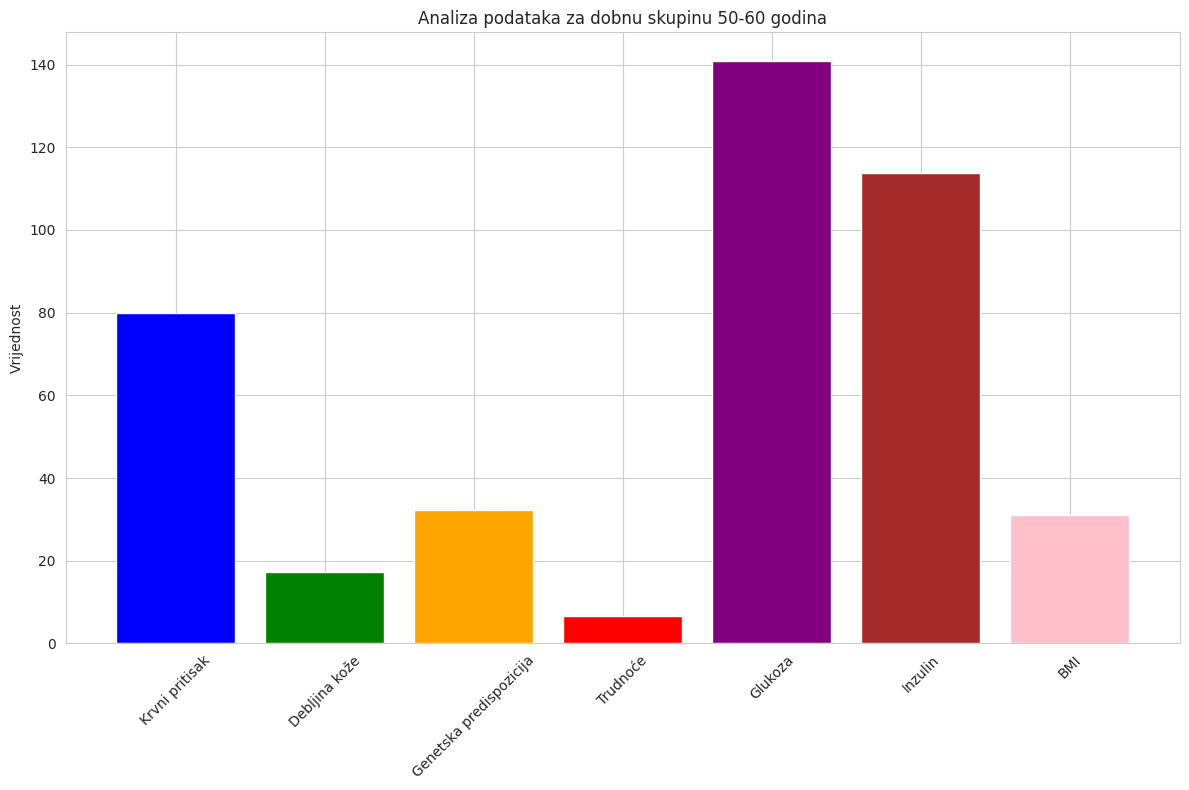

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtriranje podataka za dobnu skupinu između 50 i 60 godina
df_filtered = df[(df['Age'] >= 50) & (df['Age'] <= 60)]

# Analiza podataka
mean_blood_pressure = df_filtered['BloodPressure'].mean()
mean_skin_thickness = df_filtered['SkinThickness'].mean()
genetic_predisposition_count = df_filtered['DiabetesPedigreeFunction'].sum()
mean_pregnancies = df_filtered['Pregnancies'].mean()
mean_glucose = df_filtered['Glucose'].mean()
mean_insulin = df_filtered['Insulin'].mean()
mean_bmi = df_filtered['BMI'].mean()

# Dodavanje informacija o ishodu dijabetesa
outcome_diabetes = df_filtered['Outcome']  # Pretpostavljamo da 'Outcome' označava prisutnost (1) ili odsutnost (0) dijabetesa

# Analiza povezanosti s ishodom dijabetesa
mean_blood_pressure_diabetes = df_filtered[df_filtered['Outcome'] == 1]['BloodPressure'].mean()
mean_glucose_diabetes = df_filtered[df_filtered['Outcome'] == 1]['Glucose'].mean()
mean_insulin_diabetes = df_filtered[df_filtered['Outcome'] == 1]['Insulin'].mean()

# Priprema podataka za graf
categories = ['Krvni pritisak', 'Debljina kože',
              'Genetska predispozicija',
              'Trudnoće', 'Glukoza',
              'Inzulin', 'BMI']
values = [mean_blood_pressure, mean_skin_thickness, genetic_predisposition_count,
          mean_pregnancies, mean_glucose, mean_insulin, mean_bmi]

# Stvaranje grafa
plt.figure(figsize=(12, 8))  # Povećajmo veličinu grafa radi bolje čitljivosti
plt.bar(categories, values, color=['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink'])
plt.title('Analiza podataka za dobnu skupinu 50-60 godina')
plt.ylabel('Vrijednost')
plt.xticks(rotation=45)  # Rotiraj oznake x osi za 45 stupnjeva radi bolje čitljivosti
plt.tight_layout()  # Osigurava da se sve oznake na grafu prikažu
plt.show()



Analiza podataka sugerira da je u ovoj dobnoj skupini najizraženiji problem povišena razina glukoze i inzulina, što ukazuje na mogućnost prisutnosti dijabetesa tipa 2 ili inzulinske rezistencije. Krvni tlak također pokazuje povećanje, što dodatno povećava rizik od kardiovaskularnih bolesti. S obzirom na ove rezultate, važno je dovesti zaključak da zaista glukoza, inzulin i krvni pritisak imaju veliki uticaj za razvoj dijabetesa u ovoj dobnoj skupini i da su jedni od ključnih faktora. *Napomena: Vršeno je ispitivanje osoba sa dijabetesom.*


---
S ovime se potvrđuje hipotezu da ispitanici u starosnoj skupini između 50 i 60 godina imaju najveću vjerojatnost za oboljenjem od dijabetesa. Visoke razine glukoze i inzulina, kao i povišeni krvni tlak, sugeriraju na prisutnost metaboličkih problema koji su često povezani s razvojem dijabetesa tipa 2. Ovi rezultati naglašavaju važnost rane detekcije, prevencije i upravljanja dijabetesom, posebno u starijim dobima.


# **Kako se povećan nivo glukoze kod trudnica može odraziti na razvijanje dijabetesa?**

Gestacijski dijabetes karakterizira povišena razina glukoze u krvi kod trudnica koje prije trudnoće nisu imale dijabetes.

 Glavni cilj je istražiti moguću povezanost između gestacijskog dijabetesa i kasnijeg razvoja dijabetesa tipa 2 kod žena.

1. Povećan rizik od razvoja dijabetesa kod trudnica s gestacijskim dijabetesom:

Studije su pokazale da žene koje razviju gestacijski dijabetes imaju povećan rizik od razvoja dijabetesa tipa 2 kasnije u životu.

2. Mehanizmi povezanosti između gestacijskog dijabetesa i dijabetesa tipa 2:

Postoji nekoliko mehanizama koji mogu objasniti povezanost između gestacijskog dijabetesa i dijabetesa tipa 2:

1. Inzulinska rezistencija: Trudnoća može izazvati inzulinsku rezistenciju, što dovodi do povećane razine glukoze u krvi. Kod nekih žena, ova inzulinska rezistencija može postati trajna, što ih čini sklonijima razvoju dijabetesa tipa 2.
2. Genetska predispozicija: Genetski faktori igraju važnu ulogu u razvoju dijabetesa tipa 2. Žene koje su već sklone gestacijskom dijabetesu mogu imati i veći genetski rizik za razvoj dijabetesa tipa 2.


---
Nakon postavljanja svih ovih hipoteza potrebno je krenuti sa ispitivanjem podataka.


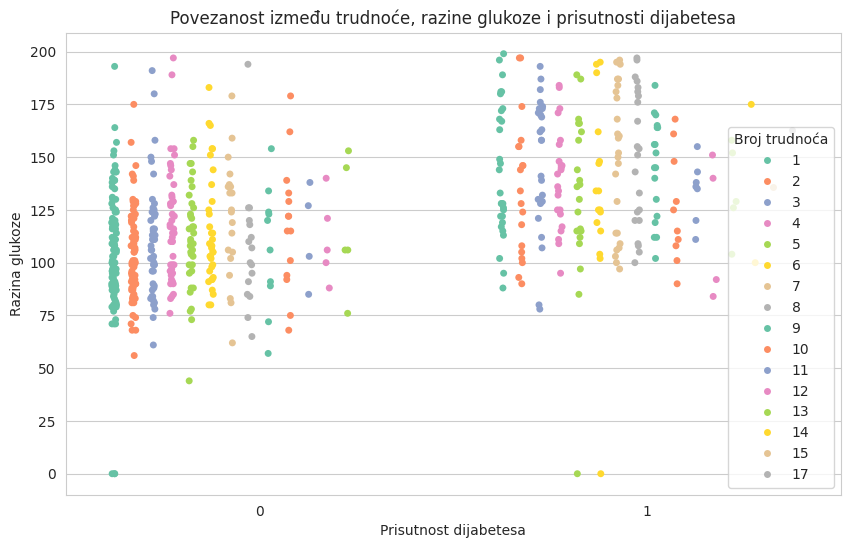

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Učitavanje baze podataka


# Filtriranje podataka samo za trudnice
df_pregnant = df[df['Pregnancies'] > 0]

# Stvaranje grafa
plt.figure(figsize=(10, 6))

sns.stripplot(x="Outcome", y="Glucose", hue="Pregnancies", data=df_pregnant, palette="Set2", dodge=True)

# Dodavanje oznaka i naslova
plt.title('Povezanost između trudnoće, razine glukoze i prisutnosti dijabetesa')
plt.xlabel('Prisutnost dijabetesa')
plt.ylabel('Razina glukoze')
plt.legend(title='Broj trudnoća')
plt.show()




Grafikon pokazuje da je među trudnicama s višom razinom glukoze u krvi veći broj trudnica s dijabetesom. Na primjer, od 100 trudnica s razinom glukoze od 150 mg/dL ili višom, oko 20 ima dijabetes. S druge strane, od 100 trudnica s razinom glukoze ispod 90 mg/dL samo jedna ima dijabetes.

Zaključak iz grafikona je da je trudnoća značajan faktor rizika za razvoj dijabetesa. Trudnice s visokom razinom glukoze u krvi imaju mnogo veću vjerojatnost da će dobiti dijagnozu dijabetesa nego one s normalnom razinom glukoze u krvi.

Rezultat grafa je da je trudnoća značajan čimbenik rizika za razvoj dijabetesa. Trudnice s povišenim razinama glukoze imaju mnogo veću šansu da im bude dijagnosticiran dijabetes nego one s normalnim razinama glukoze.

**Da li je važno češće kontrolisati trudnoću ako trudnica ima genetsku predispoziciju za razvoj dijabetesa?**

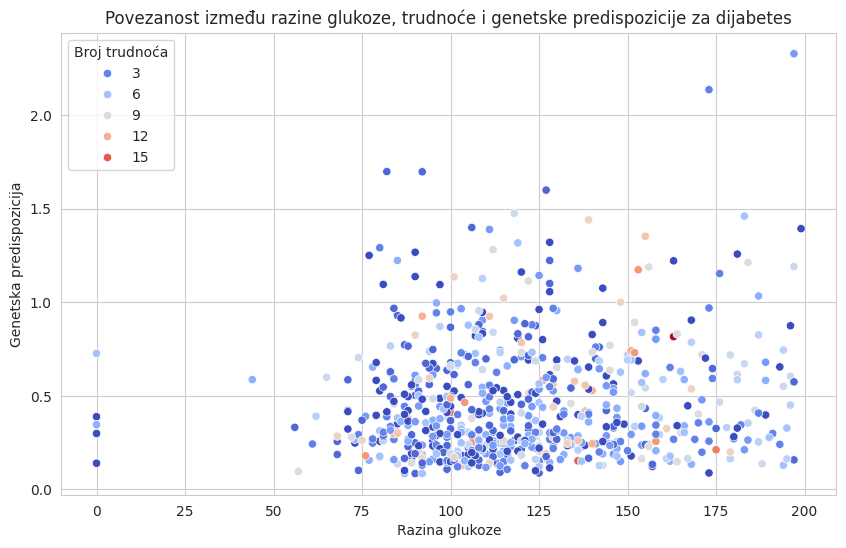

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Filtriranje podataka samo za trudnice
df_pregnant = df[df['Pregnancies'] > 0]

# Stvaranje scatter plot-a
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='DiabetesPedigreeFunction', hue='Pregnancies', data=df_pregnant, palette='coolwarm')
plt.title('Povezanost između razine glukoze, trudnoće i genetske predispozicije za dijabetes')
plt.xlabel('Razina glukoze')
plt.ylabel('Genetska predispozicija')
plt.legend(title='Broj trudnoća')
plt.show()


Ovaj graf prikazuje kako su razina glukoze, broj trudnoća i genetska predispozicija za dijabetes međusobno povezani kod trudnica. Detaljno objašnjenje:

1. Razina glukoze i broj trudnoća:
Na x-osi je prikazana razina glukoze, dok je na y-osi prikazan broj trudnoća. Svaka tačka na grafu predstavlja jednu trudnicu.
Graf pokazuje da su žene s višom razinom glukoze obično trudne. To se vidi po tome što su točke više na grafu (veći broj trudnoća) kada je razina glukoze veća.
2. Veličina točke kao indikator genetske predispozicije za dijabetes:
Veličina točke predstavlja genetsku predispoziciju za dijabetes. Što je točka veća, to znači da je genetska predispozicija jača.
Dakle, veće točke označavaju žene s većom genetskom predispozicijom za dijabetes.
3. Veza između razina glukoze, genetske predispozicije i broja trudnoća:
Grafikon također pokazuje da su žene s većom genetskom predispozicijom za dijabetes vjerojatnije trudne s višom razinom glukoze.
To se vidi po tome što su veće tačke (veća genetska predispozicija) obično više na grafu (veći broj trudnoća) kada je razina glukoze viša.

---

Zaključak:
Grafikon sugerira da su razina glukoze i genetska predispozicija za dijabetes čimbenici rizika za dijabetes kod trudnica.
Žene s višom razinom glukoze i žene s većom genetskom predispozicijom za dijabetes vjerojatnije su trudne s višom razinom glukoze.
Ovi rezultati naglašavaju važnost praćenja razine glukoze tijekom trudnoće, posebno kod žena s genetskom predispozicijom za dijabetes.

# **Korelacijska matrica svih faktora uticaja na dijabetes**

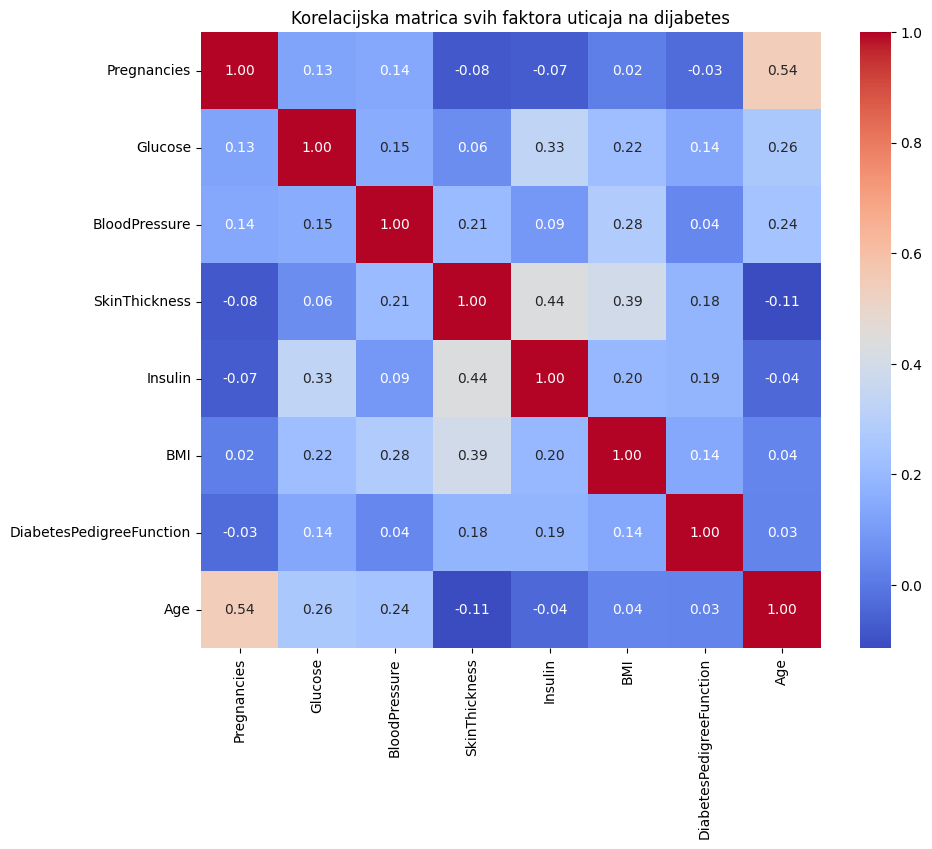

In [ ]:
# Izostavite kolone koje nisu numeričke
numerical_df = df.select_dtypes(include=['number'])

# Izračunajte korelacije
correlation_matrix = numerical_df.corr()

# Vizualizirajte korelacijsku matricu
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacijska matrica svih faktora uticaja na dijabetes")
plt.show()



Ovaj graf omogućava nam vizualnu identifikaciju uzoraka povezanosti ili nedostatka povezanosti između različitih varijabli te pomaže nam u prepoznavanju varijabli koje imaju snažne ili slabe veze među sobom.

**1) Trudnoća**
- Vidimo da starosna dob od svih podataka najviše utiče na dijabetes u trudnoći, a njihov faktor korelacije je najveći u svim izračunatim korelacijama te označava da postoji umjerena pozitivna linearna veza između dvije varijable.
- Faktori korelacije debljine kože, insulina i genetske predispozicije su u minusu što znači da imamo nedostatak kauzalne veze sa ovim elementima

**2) Glukoza**
- Primjećujemo postoji izražena sličnost između faktore korelacije glukoze sa svim ostalim elementima

**3) Krvni pritisak**
- Za krvni pritisak možemo reći isto kao i za glukozu

**4) Debljina kože**
- Među mjerenim varijablama, debljina kože ima najizraženiju korelaciju s razinom insulina i indeksom tjelesne mase (BMI). Dok negativnu korelaciju ima sa trudnoćom i godinama

**5)Insulin**
- Insulin ima značajan faktor korelacije sa glukozom

**6) BMI**

- BMI ima slične i umjerene korelacije sa svim elementima, a najviše vrijednosti pronalazimo u debljini kože, krvnom pritisku i glukozi

**7) Genetska predispozicija**
- Ima jako malu relaciju sa svim elementima, osim sa trudnoćom gdje ima negativnu vrijednost.

**8) Starosna dob**
- Starosna dob ima umjerenu pozitivnu linearnu vezu s dijabetesom u trudnoći. To sugerira da starije žene imaju veću vjerovatnoću za razvoj dijabetesa tokom trudnoće. A u svim ostalim elementima su jako bliske vrijednosti.

***Zaključak***

Osiguravajući se da korelacija nije negativna, glukoza pokazuje umjerenu povezanost s ostalim elementima u analizi. To sugerira da promjene u razini glukoze mogu biti povezane s promjenama u drugim varijablama, ali ta veza nije prejaka. U stvarnom životu, ovo može značiti da promjene u glukozi ne moraju nužno biti direktno povezane s promjenama u drugim faktorima, ali bi trebale biti uzete u obzir prilikom analize i praćenja zdravstvenih stanja kao što je dijabetes.

Najveće faktore korelacije pronalazimo u vezi insulina i debljine kože te trudnoće i starosti. Visoka korelacija između insulina i debljine kože može biti posljedica činjenice da se debljina kože često koristi kao pokazatelj pretilosti. Prekomjerna tjelesna težina često ide ruku pod ruku s otpornošću na insulin i smanjenom osjetljivošću na djelovanje insulina u tijelu, što može dovesti do razvoja dijabetesa. Stoga, visoka korelacija između insulina i debljine kože može ukazivati na važnu ulogu pretilosti u razvoju dijabetesa.
Korelacija između trudnoće i starosti može biti rezultat činjenice da se gestacijski dijabetes češće javlja kod starijih trudnica. Starenje može povećati rizik od gestacijskog dijabetesa zbog promjena u metabolizmu i hormonalnim promjenama. Dakle, visoka korelacija između trudnoće i starosti može ukazivati na važnost uzimanja u obzir dobi kao faktora rizika prilikom procjene gestacijskog dijabetesa.

#**Može li debljina kože, kao vanjski pokazatelj, ukazati na rizik od visokog krvnog pritiska kod osoba s visokim BMI-jem?**

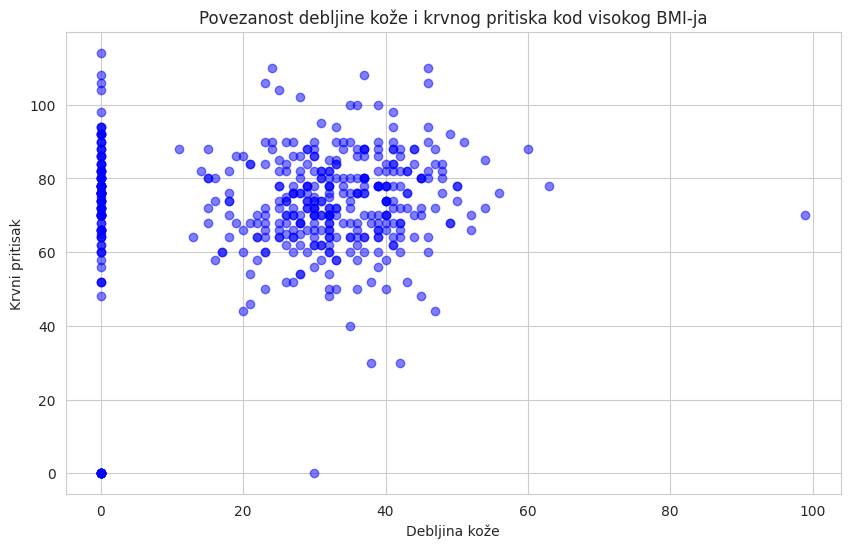

In [ ]:
filtrirani_podaci = df[df['BMI'] > 30]
podaci_skin_pressure = filtrirani_podaci[['SkinThickness', 'BloodPressure']]
plt.figure(figsize=(10, 6))
plt.scatter(podaci_skin_pressure['SkinThickness'], podaci_skin_pressure['BloodPressure'], color='blue', alpha=0.5)
plt.title('Povezanost debljine kože i krvnog pritiska kod visokog BMI-ja')
plt.xlabel('Debljina kože')
plt.ylabel('Krvni pritisak')
plt.grid(True)
plt.show()

Zanimaju nas samo osobe koje imaju visok BMI, zbog toga nećemo uzeti u obzir sve podatke, već samo one koji zadvoljavaju naš kriterij. Najprije smo filtrirali podatke na način da se uzimaju samo vrijednosti veće od 30, jer nam je baš ta skupina od interesa. Shodno tome, učitavaju se podaci i preostale dvije varijeble, tj. vrijednosti krvnog pritiska i debljine kože.

Graf prikazuje raspršeni dijagram koji prikazuje vezu između debljine kože i krvnog pritiska kod osoba s visokim BMI-jem. Visoki BMI je povezan s rizikom od različitih zdravstvenih problema, uključujući visoki krvni pritisak i povećanu debljinu kože.

Tačke na grafikonu predstavljaju pojedinačne osobe. Jačina plave boje tačke predstavlja broj osoba kojima je mjerena i debljina kože i krvni pritisak.

Graf pokazuje da postoji pozitivna korelacija između debljine kože i krvnog pritiska. To znači da što je debljina kože veća, to je i krvni pritisak veći. Ova korelacija je statistički značajna, što znači da je malo vjerojatno da je slučajna. Debljina kože je pokazatelj količine masnog tkiva u tijelu. Masno tkivo proizvodi hormone koji mogu povisiti krvni pritisak. Obje varijable mogu biti povezane sa različitim faktorima, kao što su genetika ili način života.

Na samom grafu vidimo značajan broj tačaka koje su skoncentrisane na dijelu gdje debljina kože ima vrijednost jednaku nuli. Već je spomenuto, kod analize jedne od prethodno kreiranih vizualizacija, da je uzrok te pojave nezanemariv broj podataka koji se odnose na debljinu kože čija je stvarna vrijednost nula.

Iako ne mora značiti u baš svim slučajevima, debljina kože, kao vanjski pokazatelj, može ukazivati na rizik od visokog krvnog pritiska kod osoba s visokim BMI-jem.

#**Važnost statističke analize**

Utvrđivanje faktora rizika povezanih s dijabetesom omogućava dublje razumijevanje mehanizama bolesti i identifikaciju ključnih intervencijskih tačaka za prevenciju i upravljanje dijabetesom u životu. Analiza faktora rizika za dijabetes, poput genetske predispozicije, pretilosti, loših prehrambenih navika i nedovoljne tjelesne aktivnosti, omogućava zdravstvenim stručnjacima i javnim zdravstvenim agencijama da se fokusiraju na specifične populacijske skupine radi stvaranja preventivnih programe i intervencija. Na primjer, na osnovu saznanja da je prekomjerna tjelesna težina važan faktor rizika za dijabetes, mogu se razviti kampanje koje promoviraju zdravu ishranu i redovitu tjelesnu aktivnost kako bi se smanjio rizik od dijabetesa u populaciji ili pak obratiti pažnja na trudnice sa genetskom predispozicijom za dijabetes i visokim nivoom glukoze. Identificiranje genetskih faktora rizika omogućava personalizirane medicinske strategije za rane intervencije i praćenje osoba s povećanim rizikom od razvoja dijabetesa. Ovo prošireno razumijevanje faktora rizika osigurava efikasnije zdravstvene programe i individualizirane terapije koje imaju za cilj smanjenje prevalencije dijabetesa i poboljšanje zdravlja populacije.

